In [5]:
#All imports used throughout testing
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import lightkurve as lk
import astropy.units as u
import tkinter as tk
from tkinter import ttk
from matplotlib.figure import Figure
import matplotlib
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import csv
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import silhouette_score, silhouette_samples
import warnings
from sklearn.exceptions import ConvergenceWarning
from datetime import datetime
from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import random
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from numpy import format_float_positional



In [6]:
#This function separates a pandas dataframe into separate smaller ones by variable star type using the 'Type' column from VisieR https://vizier.cds.unistra.fr/viz-bin/VizieR-3
#The types focused on for this project are 'MISC' (miscellaneous), 'CST' (constant), 'RR' (RR Lyrae), 'EC' (contact eclipsing binary system), 'ED' (detached eclipsing binary system), 'DSCT' (delta scuti), 'DCEP' (classical cepheid/delta cephei-type variables), 'GDOR' (gamma doradus)
#Subtypes listed in "VARIABLE STAR TYPE DESIGNATIONS IN VSX" https://www.aavso.org/vsx/index.php?view=about.vartypes are included in these general categories

def septypes(dataset):  #Input a pandas dataframe that includes a 'Type' column from VisieR
    nmisc = []  #Initializing empty lists where the indices where there is not a specific star type will be appended, for masking
    ncst = []
    nrr = []
    ned = []
    nec = []
    ndsct = []
    ndcep = []
    ngdor = []

    for i in range(len(dataset['Type'])):     #Loops through each index in the dataset
        if 'MISC' not in dataset['Type'][i]:   #If a specific star type or any of its subtypes are not found in the 'Type',the index will be appended to the corresponding list
            nmisc.append(i)

        if 'CST' not in dataset['Type'][i]:
            ncst.append(i)

        if 'RR' not in dataset['Type'][i]:
            nrr.append(i)

        if 'EC' not in dataset['Type'][i]:
            if 'EW' not in dataset['Type'][i]:
                nec.append(i)

        if 'ED' not in dataset['Type'][i]:
            if 'EA' not in dataset['Type'][i]:
                if 'ESD' not in dataset['Type'][i]:
                    if 'EB' not in dataset['Type'][i]:
                        ned.append(i)

        if 'DSCT' not in dataset['Type'][i]:
            if 'HADS' not in dataset['Type'][i]:
                ndsct.append(i)

        if 'DCEP' not in dataset['Type'][i]:
            ndcep.append(i)
        
        if 'GDOR' not in dataset['Type'][i]:
            ngdor.append(i)

    MISC = dataset.drop(nmisc)  #Dropping all indices where the 'Type' doesn't match for each category
    CST = dataset.drop(ncst)
    RR = dataset.drop(nrr)
    EC = dataset.drop(nec)
    ED = dataset.drop(ned)
    DSCT = dataset.drop(ndsct)
    DCEP = dataset.drop(ndcep)
    GDOR = dataset.drop(ngdor)

    for val in MISC.Type.unique():  #Ensuring for each category that all the 'Type' names are the same for machine learning purposes
        MISC.replace(to_replace=val, value='MISC', inplace=True)  #This could probably be consolidated into a smaller chunk of code with a bit of time
    MISC = MISC.reset_index()
    MISC = MISC.drop('index',axis = 1)

    for val in CST.Type.unique():
        CST.replace(to_replace=val, value='CST', inplace=True)
    CST = CST.reset_index()
    CST = CST.drop('index',axis = 1)

    for val in RR.Type.unique():
        RR.replace(to_replace=val, value='RR', inplace=True)
    RR = RR.reset_index()
    RR = RR.drop('index',axis = 1)

    for val in EC.Type.unique():
        EC.replace(to_replace=val, value='EC', inplace=True)
    EC = EC.reset_index()
    EC = EC.drop('index',axis = 1)

    for val in ED.Type.unique():
        ED.replace(to_replace=val, value='ED', inplace=True)
    ED = ED.reset_index()
    ED = ED.drop('index',axis = 1)

    for val in DSCT.Type.unique():
        DSCT.replace(to_replace=val, value='DSCT', inplace=True)
    DSCT = DSCT.reset_index()
    DSCT = DSCT.drop('index',axis = 1)

    for val in DCEP.Type.unique():
        DCEP.replace(to_replace=val, value='DCEP', inplace=True)
    DCEP = DCEP.reset_index()
    DCEP = DCEP.drop('index',axis = 1)

    for val in GDOR.Type.unique():
        GDOR.replace(to_replace=val, value='GDOR', inplace=True)
    GDOR = GDOR.reset_index()
    GDOR = GDOR.drop('index',axis = 1)

    return(MISC,CST,RR,EC,ED,DSCT,DCEP,GDOR)  #Returns separate pandas dataframes containing only the specific type of star that correlates with the variable name

In [7]:
#This function allows you to clean a dataset that includes one "Type" by returning a csv file that includes the word "yes" or "no" for each index in the dataset depending on which button is pressed. When 'yes' or the y key is pressed, the lightcurve of will be saved as a jpeg file
#Pandas "dataset" must have columns 'TIC_ID','Sector','Camera','CCD', and 'Type' ('Type' must all be the same type)
#'newfilename' is the name that you want the CSV to be saved as
#'foldername' is the name of the folder that you want the created folder of lightcurves to go into
#'seccam' is a name for the sector and camera that the dataset is from, example 'sec15cam3'
#max and min are the maximum and minimum period values to have a window pop up, if the period is outside of these values, 'no' will be appended to the csv file
#Right now, only sectors 1,2,3,4,5,15,16, and 17 will work with this function
def clean(dataset,newfilename,foldername,seccam,max,min):  

    cleaned = [] #Initializing an empty list where 'yes' or 'no' will be appended depending on whether or not a light curve was labelled correctly 

    for i in range(len(dataset['TIC_ID'])): #Looping to get a light curve for each index in the dataset
    
        TICID = dataset['TIC_ID'][i]  
        SECTOR = dataset['Sector'][i]
        CAMERA = dataset['Camera'][i]
        CCD = dataset['CCD'][i]
        
        #A different url is used to download the lightcurve data for sectors 1-5 vs sectors 15-17
        if SECTOR in ['sector01','sector02','sector03','sector04','sector05']:  
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/clean/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"
        if SECTOR in ['sector15','sector16','sector17']:
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/detrend/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"

        os.system(f"wget {url} -O {TICID}_{SECTOR}_{CAMERA}_{CCD}.lc > /dev/null 2>&1") #Collecting light curve data for the index
        data = pd.read_csv(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc",delimiter=' ',header=None,names=['time','magnitude','error'])
        data = data.to_numpy(dtype=float)
    
        if np.any(np.isnan(data)) or np.any(np.isinf(data)):  #Checking if there are any nan or inf in the light curve data and skipping the index if there are
            cleaned.append('no')
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc")
            continue
            
        time = data[:,0]
        magnitude = data[:,1]
        
        lc = lk.LightCurve(time,magnitude).remove_outliers(sigma=5.0,return_mask = False) #
        pg = lc.to_periodogram(minimum_period=0.025*u.day, maximum_period=20*u.day,oversample_factor=10) #Using lightkurve to find the period with max power using a lomb-scargle periodogram
        phase = ((time-time[0])/pg.period_at_max_power.value) - np.floor((time-time[0])/pg.period_at_max_power.value)
        phase2 = [phase-1.0,phase]
        mag = [magnitude,magnitude]
        
        def plots(ax1,ax2,ax3):  #Defining a function that creates a plot with subplots: scatter plot of magnitude vs time, lomb-scargle periodogram, and a phase folded plot of the magnitude at the period at max power
            lc.scatter(ax=ax1)
            pg.plot(ax=ax2)
            ax3.scatter(phase2,mag,marker = ".",s = 5)

        if pg.period_at_max_power.value > max:  #Appending 'no' to the list if the period is greater than the maximum value
            cleaned.append('no')

        elif pg.period_at_max_power.value < min: #Appending 'no' to the list if the period is less than the minimum value
            cleaned.append('no')

        else:
        
            window = tk.Tk()  #Creating a GUI using tkinter
            window.title(f"Is this a {dataset['Type'][i]}? Index {i}")
            window.geometry("500x1000")

            fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(18,25))

            ax2.text(0.5, 0.8, f'Within (0.025,20) period = {pg.period_at_max_power}', transform=ax2.transAxes, fontsize=15)

            ax1.invert_yaxis()
            ax3.invert_yaxis()
            ax1.set_ylabel('Magnitude')
            ax3.set_xlabel('Phase')
            ax3.set_ylabel('Magnitude')

            plots(ax1,ax2,ax3)
            plt.suptitle(f"{dataset['Type'][i]}",fontsize = 30)

            canvas = FigureCanvasTkAgg(fig, master=window)
            canvas.draw()

            canvas_widget = canvas.get_tk_widget()
            canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)

            def yes_command():  #Defining a button that will append "yes" to the list if the button is pressed
                cleaned.append('yes')
                if not os.path.exists(f"{foldername}/{seccam}_{dataset['Type'][i]}_images"):
                    os.makedirs(f"{foldername}/{seccam}_{dataset['Type'][i]}_images")
                plt.savefig(f"{foldername}/{seccam}_{dataset['Type'][i]}_images/{TICID}_{SECTOR}_{CAMERA}_{CCD}.jpg")
                plt.close(fig)
                window.update_idletasks()
                window.destroy()
        
            def no_command(): #Defining a button that will append "no" to the list if the button is pressed
                cleaned.append('no')
                plt.close(fig)
                window.destroy()
        
            def on_key_press(event):  #The buttons can be finnicky so this block of code will allow the y key to be used in place of the 'yes' button and the n key in place of the 'no' button
                if event.keysym == 'y':
                    yes_button.invoke()
                elif event.keysym == 'n':
                    no_button.invoke()
    
            yes_button = ttk.Button(window, text="Yes", command=yes_command)
            yes_button.pack(side=tk.LEFT)
    
            no_button = ttk.Button(window, text="No", command=no_command)
            no_button.pack(side=tk.RIGHT)
    
            window.bind('<y>', on_key_press)
            window.bind('<n>', on_key_press)

            window.mainloop()
    
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc") #removing the file with the light curve data to take up less space
        
            if i == (len(dataset['TIC_ID'])-1):  #Creating a csv file with all the 'yes' and 'no' values
                with open(f'{newfilename}.csv', 'w', newline='') as csvfile:
                    writer = csv.writer(csvfile)
                    for item in cleaned:
                        writer.writerow([item])
    ;

In [30]:
#This is a function that outputs the columns that cause the highest accuracy (or silhouette for kmeans) score when put through a machine learning classifier
#'dataset' is a pandas dataset that includes all 'types' any columns necessary for machine learning 
#cols is a list of all column names necessary for machine learning that are in the dataset
#classifier is a machine learning classifier, example: RandomForestClassifier(random_state=20,n_estimators=25)
#numcols is the maximum number of columns that you want to find the highest accuracy score with, recommended to choose 3 or less because otherwise it will take very long for the code to run, but 5 is the maximum
#silhouette is either True or False depending on whether or not a silhouette score is needed instead of an accuracy score
def bestcols(dataset,cols,classifier,numcols,silhouette):
    start_time = datetime.now()

    dict2 = {} #Empty dictionaries are initialized for each number of columns that can be chosen
    dict3 = {}
    dict4 = {}
    dict5 = {}

    for val in cols: #This first chunk of code loops through combinations of 2 columns, forming a training and testing set for each
        for val2 in cols:
            vals2 = [val,val2]
            if len(vals2) == len(set(vals2)) and numcols >= len(vals2):
                X = dataset[vals2]
                X = X.apply(pd.to_numeric)
                Y = dataset['Type']
                X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.25, train_size=0.75)
                
                cl = classifier
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
                    cl.fit(X_train, y_train) #Each combinaiton of columns is run through the machine learning classifier
                if silhouette == False: #If silhouette is False, accuracy score is used
                    ypred = cl.predict(X_test)
                    score = metrics.accuracy_score(y_test, ypred)
                if silhouette == True: #If silhouette is True, silhouette score is used
                    ypred = cl.fit_predict(X_test)
                    score = silhouette_score(X_test, ypred)

                dict2.update({score:vals2}) #All the scores for each combination of 2 columns is added to dict2
                
            for val3 in cols: #Previous comments apply to next 3 chunks of code, this one is for combinations of 3 columns and so on
                vals3 = [val,val2,val3]
                if len(vals3) == len(set(vals3)) and numcols >= len(vals3):
                
                    X = dataset[vals3]
                    X = X.apply(pd.to_numeric)
                    Y = dataset['Type']
                    X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.25, train_size=0.75)
                
                    cl = classifier
                    with warnings.catch_warnings():
                        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
                        cl.fit(X_train, y_train)
                    if silhouette == False:
                        ypred = cl.predict(X_test)
                        score = metrics.accuracy_score(y_test, ypred)
                    if silhouette == True:
                        ypred = cl.fit_predict(X_test)
                        score = silhouette_score(X_test, ypred)

                    dict3.update({score:vals3})
                
                for val4 in cols:
                    vals4 = [val,val2,val3,val4]
                    if len(vals4) == len(set(vals4)) and numcols >= len(vals4):
                    
                        X = dataset[vals4]
                        X = X.apply(pd.to_numeric)
                        Y = dataset['Type']
                        X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.25, train_size=0.75)
                
                        cl = classifier
                        with warnings.catch_warnings():
                            warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
                            cl.fit(X_train, y_train)
                        if silhouette == False:
                            ypred = cl.predict(X_test)
                            score = metrics.accuracy_score(y_test, ypred)
                        if silhouette == True:
                            ypred = cl.fit_predict(X_test)
                            score = silhouette_score(X_test, ypred)

                        dict4.update({score:vals4})
                        
                    for val5 in cols:
                        vals5 = [val,val2,val3,val4,val5]
                        if len(vals4) == len(set(vals5)) and numcols >= len(vals5):
                    
                            X = dataset[vals5]
                            X = X.apply(pd.to_numeric)
                            Y = dataset['Type']
                            X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.25, train_size=0.75)
                
                            cl = classifier
                            with warnings.catch_warnings():
                                warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
                                cl.fit(X_train, y_train)
                            if silhouette == False:
                                ypred = cl.predict(X_test)
                                score = metrics.accuracy_score(y_test, ypred)
                            if silhouette == True:
                                ypred = cl.fit_predict(X_test)
                                score = silhouette_score(X_test, ypred)

                            dict5.update({score:vals5})
                    
    if numcols >= len(vals2):  #These chunks of code find the combination of 2,3,4 and 5 columns in the dictionaries that have the highest accuracy/silhouette scores, depending on what numcols is, and prints the score along with the column names
        scores2 = list(dict2.keys())
        maxscore2 = max(scores2)
        cols2 = dict2[maxscore2]
        print(maxscore2,cols2)
    
    if numcols >= len(vals3):           
        scores3 = list(dict3.keys())
        maxscore3 = max(scores3)
        cols3 = dict3[maxscore3]
        print(maxscore3,cols3)
    
    if numcols >= len(vals4):
        scores4 = list(dict4.keys())
        maxscore4 = max(scores4)
        cols4 = dict4[maxscore4]
        print(maxscore4,cols4)
        
    if numcols >= len(vals5):
        scores5 = list(dict5.keys())
        maxscore5 = max(scores5)
        cols5 = dict5[maxscore5]
        print(maxscore5,cols5)

    X = dataset.drop(columns = ['Type']) #This runs the machine learning classifier with all columns and prints the score under the combinations of fever columns
    X = X.apply(pd.to_numeric)
    Y = dataset['Type']
    X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=.25, train_size=.75)

    cl = classifier
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn")
        cl.fit(X_train, y_train)
    ypred = cl.predict(X_test)
    score = metrics.accuracy_score(y_test, ypred)

    print(score,"All columns")

    end_time = datetime.now() #The time taken to run the cell is printed for reference, because with high numcols it can take a long time
    print('Duration: {}'.format(end_time - start_time))

In [31]:
#This function finds 'Vmag' - 'Kmag' and 'w1mag' - 'w4mag' and saves them as new columns in the dataset
#'dataset' is a pandas dataframe that includes the columns 'Vmag','Kmag','w1mag', and 'w4mag'
def magdiff(dataset):
    VmKmag = [] 
    for i in range(len(dataset['Kmag'])): #For each index in the dataset, the value for Kmag is subtracted from the value for Vmag and appended to a list
        VmKmag.append(float(dataset['Vmag'][i]) - float(dataset['Kmag'][i]))
    
    w1mw4mag = []
    for i in range(len(dataset['w1mag'])): #For each index in the dataset, the value for w4mag is subtracted from the value for w1mag and appended to a list
        w1mw4mag.append(float(dataset['w1mag'][i]) - float(dataset['w4mag'][i]))

    dict = {'VmKmag': VmKmag, 'w1mw4mag': w1mw4mag} #The lists of values are given their corresponding column names in a dictionary, then converted to a pandas dataframe
   
    calcs = pd.DataFrame(dict)
   
    datasetwcalcs = pd.concat([dataset, calcs], axis=1) #The new columns 'VmKmag' and 'w1mw4mag' are added to the original dataset, then the columns 'w1mag','w4mag','Vmag','Kmag' are dropped
    datasetwcalcs = datasetwcalcs.drop(['w1mag','w4mag','Vmag','Kmag'], axis=1)
    return datasetwcalcs #The new dataset with the necessary magnitude differences is returned

In [32]:
#This function cleans a dataset that was put through the "clean" function by adding the CSV file returned by the "clean" function as a column to the dataset used, then dropping all the indices where the new column has "no"
#'dataset' is a pandas dataframe that was put through the "clean" function, or the entire dataset with all types as long as .head() was used for the single type dataset put into the "clean" function
#'type' is the star type of the dataset put through the "clean" function
#'typecleanedfilename' is the name of the CSV file that was returned by the 'clean' function, containing the strings 'yes' and 'no'
def cleaneddata(dataset,type,typecleanedfilename):
    
    nottypes = [] #If the entire original dataset is used as 'dataset', the indices where the 'Type' column is not equal to the type inputted will be appended to this list

    if type == 'MISC':
        for i in range(len(dataset['Type'])):
            if 'MISC' not in dataset['Type'][i]:
                nottypes.append(i)

    if type == 'CST':
        for i in range(len(dataset['Type'])):
            if 'CST' not in dataset['Type'][i]:
                nottypes.append(i)

    if type == 'RR':
        for i in range(len(dataset['Type'])):
            if 'RR' not in dataset['Type'][i]:
                nottypes.append(i)

    if type == 'EC':
        for i in range(len(dataset['Type'])):
            if 'EC' not in dataset['Type'][i]:
                if 'EW' not in dataset['Type'][i]:
                    nottypes.append(i)

    if type == 'ED':   
        for i in range(len(dataset['Type'])):             
            if 'ED' not in dataset['Type'][i]:
                if 'EA' not in dataset['Type'][i]:
                    if 'ESD' not in dataset['Type'][i]:
                        if 'EB' not in dataset['Type'][i]:
                            nottypes.append(i)

    if type == 'DSCT': 
        for i in range(len(dataset['Type'])):
            if 'DSCT' not in dataset['Type'][i]:
                if 'HADS' not in dataset['Type'][i]:
                    nottypes.append(i)

    if type == 'DCEP': 
        for i in range(len(dataset['Type'])):
            if 'DCEP' not in dataset['Type'][i]:
                nottypes.append(i)

    if type == 'GDOR': 
        for i in range(len(dataset['Type'])):     
            if 'GDOR' not in dataset['Type'][i]:
                nottypes.append(i)

    types = dataset.drop(nottypes) #This line of code drops all indices where the "Type" column is not equal to the type inputted

    for val in types.Type.unique():
        types.replace(to_replace=val, value=type, inplace=True)

    testing = pd.read_csv(f"{typecleanedfilename}.csv", sep=',',header = None) #The CSV of 'yes' and 'no' strings is loaded in as a pandas column

    types = types.head(len(testing)) #If the entire dataset was used, this ensures that it is the same length as the CSV file
    types = types.reset_index()
    types = types.drop('index',axis = 1)

    cols = pd.concat([testing, types], axis=1) #This last chunk of code concatenates the dataset and the "yes"/"no" column, and then drops the incides where the column from the CSV files says "no"
    nos = []
    for i in range(len(cols[0])):
        if cols[0][i] == 'no':
            nos.append(i)
        
    allyes = cols.drop(nos)
    allyes = allyes.reset_index()
    cleandata = allyes.drop('index',axis = 1)
    
    return cleandata #The cleaned dataset of the single star type is returned (Indices where the CSV file returned from the 'clean' function was "yes")


In [33]:
#This is just a quick function that puts a dataset through a classifier, then concatenates the column of predicted types to the dataset
#'dataset' is a pandas dataframe with any columns needed for machine learning
#classifier is a variable name for a machine learning classifier that was previously run with a training dataset
#cols is a list of all column names necessary for machine learning that are in the dataset
def resulttypes(dataset,classifier,cols):
    predtypes = classifier.predict(dataset[cols])
    predtypes = pd.DataFrame({'PredType': predtypes})
    
    results = pd.concat([predtypes,dataset], axis=1)
    return results #Returns the inputted pandas dataframe with an added column of the predicted types from the machine learning classifier

In [34]:
#This function takes a dataset that was previously returned by the 'resulttypes' function, and creates jpeg plots for each predicted type, similar to the 'clean' function
#'dataset' is the pandas dataframe returned by the 'resulttypes' function that includes columns 'PredType','TIC_ID','Sector','Camera',and 'CCD'
#'seccam' is a name for the sector and camera that the dataset is from, example 'sec15cam3'
#'foldername' is the name of the main folder that you would like all the folders for each star type containing the light curves to go into.
#Right now, only sectors 1,2,3,4,5,15,16, and 17 will work with this function
def resultplots(dataset,seccam,foldername):

    for i in range(len(dataset['TIC_ID'])): #Looping to get a light curve for each index in the dataset
    
        TICID = dataset['TIC_ID'][i]
        SECTOR = dataset['Sector'][i]
        CAMERA = dataset['Camera'][i]
        CCD = dataset['CCD'][i]
        if SECTOR in ['sector01','sector02','sector03','sector04','sector05']: #A different url is used to download the lightcurve data for sectors 1-5 vs sectors 15-17
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/clean/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"
        if SECTOR in ['sector15','sector16','sector17']:
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/detrend/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"
        
        os.system(f"wget {url} -O {TICID}_{SECTOR}_{CAMERA}_{CCD}.lc > /dev/null 2>&1")
    
        try:
            data = pd.read_csv(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc", delimiter=' ', header=None, names=['time', 'magnitude', 'error'])
        except pd.errors.ParserError:
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc") #Removing light curve files that cause errors so that the cell continues to run instead of being stopped
            continue
        data = data.to_numpy(dtype=float) #Ensuring that the datatype is float

        if np.any(np.isnan(data)) or np.any(np.isinf(data)): #Checking if there are any nan or inf in the light curve data and skipping the index if there are
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc")
            continue
            
        time = data[:,0]
        magnitude = data[:,1]

        print(time)
        print(magnitude)
    
        lc = lk.LightCurve(time,magnitude).remove_outliers(sigma=5.0,return_mask=False)
        
        pg = lc.to_periodogram(minimum_period=0.025*u.day, maximum_period=20*u.day,oversample_factor=10) 
        phase = ((time-time[0])/pg.period_at_max_power.value) - np.floor((time-time[0])/pg.period_at_max_power.value) #Using lightkurve to find the period with max power using a lomb-scargle periodogram
        phase2 = np.concatenate((phase - 1.0, phase))
        mag = np.concatenate((magnitude, magnitude))
        
        def plots(ax1,ax2,ax3): #Defining a function that creates a plot with subplots: scatter plot of magnitude vs time, lomb-scargle periodogram, and a phase folded plot of the magnitude at the period at max power
            lc.scatter(ax=ax1)
            pg.plot(ax=ax2)
            ax3.scatter(phase2,mag,marker = ".",s = 5)

        fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(18,25))

        ax2.text(0.5, 0.8, f'Within (0.025,20) period = {pg.period_at_max_power}', transform=ax2.transAxes, fontsize=15)

        ax1.invert_yaxis()
        ax3.invert_yaxis()

        plots(ax1,ax2,ax3)
        plt.suptitle(f"{dataset['PredType'][i]}",fontsize = 30)

        if not os.path.exists(f"{foldername}/{seccam}_pred_{dataset['PredType'][i]}"):
            os.makedirs(f"{foldername}/{seccam}_pred_{dataset['PredType'][i]}") #Creating a folder inside the main folder for each specific star type if the folders do not already exist

        plt.suptitle(f"{dataset['PredType'][i]}",fontsize = 20)
        plt.savefig(f"{foldername}/{seccam}_pred_{dataset['PredType'][i]}/{TICID}_{SECTOR}_{CAMERA}_{CCD}.jpg") #Saving the jpeg image of the light curve plots
        plt.close(fig)
    
        os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc") #removing the file with the light curve data to take up less space
    ;

In [35]:
#This function prints out two plots that rank each feature on their importance based on a RandomForestClassifier. One plot shows the mean decrease in impurity, and the other plots the decrease in accuracy score 
#"test" is a dataset including all necessary features that you would like to run through a RandomForestClassifier
#"testsize" and "trainsize" is the train-test split for running through a machine learning algorithm
def importance(test,testsize,trainsize):
    X = test.drop(columns = ['Type']) 
    X = X.apply(pd.to_numeric)
    Y = test['Type']
    X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=testsize, train_size=trainsize) #Creating testing and training datasets
    
    feature_names = [f"{val}" for val in list(X.columns.values)]
    forest = RandomForestClassifier(random_state=0,n_estimators=10) #Running the data through a random forest classifier
    forest.fit(X_train, y_train)
    importances = forest.feature_importances_ 
    std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0) 
    forest_importances = pd.Series(importances, index=feature_names) #Finding the importances for each feature
    fig, ax = plt.subplots(figsize=(15,10))
    forest_importances.plot.bar(yerr=std, ax=ax) #Creating a barplot of the feature importances and using the standard deviation as error bars
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    ax.title.set_fontsize(20)     
    ax.xaxis.label.set_fontsize(16)  
    ax.yaxis.label.set_fontsize(16)
    fig.tight_layout()
    
    rf = Pipeline([("classifier", RandomForestClassifier(random_state=42))])
    rf.fit(X_train, y_train)
    result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=10) #Each feature is randomly permuted to see how much the accuracy score is affected by the feature
    sorted_importances_idx = result.importances_mean.argsort() #Sorting the importances in order from most to least
    importances = pd.DataFrame(result.importances[sorted_importances_idx].T,columns=X.columns[sorted_importances_idx])
    ax = importances.plot.box(vert=False, whis=10,figsize=(15,10)) #Creating a boxplot for the importances
    ax.set_title("Permutation Importances")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in accuracy score")
    ax.title.set_fontsize(20)      
    ax.xaxis.label.set_fontsize(16) 
    ax.yaxis.label.set_fontsize(16)
    ax.figure.tight_layout()

In [36]:
#This is an example of how I read in the data for a sector
#The typenames file is downloaded from VisieR (choose 'list of targets' then check the boxes for 'single table' and 'add your input as first column'. Then on the left choose 'max: '1' and ;-Separated-Values instead of HTML Table, then make sure only 'Type' is checked under simple constraint) after inputting a space separated file with 'ra' and 'dec' from filtergraph
#The csv file for each camera is from filtergraph with the columns 'TIC_ID','Sector','Camera','CCD','Vmag','Kmag','w1mag','w4mag','Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE' checked and downloaded as a comma-separated file

types1 = pd.read_csv('typenames_sector1.tsv', sep=';', comment='#',skip_blank_lines = False,header = 1)
types1 = types1.drop([0,1])
types1 = types1.reset_index()
types1 = types1.drop('index',axis = 1)

l = []
for i in range(len(types1['_1'])):
    if type(types1['_1'][i]) != str:
        l.append(i)
        
types1 = types1.drop(l)
types1 = types1.reset_index()
cropped1 = types1.drop('index',axis = 1)

cam1 = pd.read_csv('Sector1_camera1.csv', sep=',', comment='#', dtype = str)
cam2 = pd.read_csv('Sector1_camera2.csv', sep=',', comment='#', dtype = str)
cam3 = pd.read_csv('Sector1_camera3.csv', sep=',', comment='#', dtype = str)
cam4 = pd.read_csv('Sector1_camera4.csv', sep=',', comment='#', dtype = str)
cams = pd.concat([cam1,cam2,cam3,cam4])
cams = cams.reset_index()
alldata = cams.drop('index',axis = 1)
alldata = alldata.drop('Unnamed: 17',axis = 1)

Sector1 = pd.concat([cropped1, alldata], axis=1)

m = []
for i in range(len(Sector1['Type'])):
    if type(Sector1['Type'][i]) != str:
        m.append(i)
        
Sector1 = Sector1.drop(m)
Sector1 = Sector1.dropna(axis=0)
Sector1 = Sector1.reset_index()
Sector1 = Sector1.drop('index',axis = 1)

Sector1

,_1,Type,TIC_ID,Sector,Camera,CCD,ra,dec,Vmag,Kmag,w1mag,w4mag,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE
0,312.908065 -41.341475,MISC,389475380,sector01,1,1,312.908065,-41.341475,10.1590003967285,3.85199999809265,3.73200011253357,3.02600002288818,2932.0,43.97405,0.02801,13.916504,1257.72272,0.10409945,8.77144
1,325.888097 -43.14454,MISC,147335949,sector01,1,1,325.888097,-43.14454,10.1979999542236,4.3270001411438,4.21199989318848,3.90599989891052,3070.0,30.66852,0.0231,11.59708667,2427.2134,0.10409945,7.5651
2,316.58919 -37.587605,DSCT,115112430,sector01,1,1,316.58919,-37.587605,7.67000007629395,6.79899978637695,6.68900012969971,6.76300001144409,6955.0,5.44499,0.00342,0.19195178,1053.53284,0.19192628,7.78431
3,316.495762 -36.25944,EW,115105140,sector01,1,1,316.495762,-36.25944,7.81099987030029,6.57299995422363,6.49300003051758,6.38700008392334,6229.0,159.30206,0.08317,0.20540965,13818.54387,0.2052788,9.75553
4,320.519456 -42.76817,SRB,200644705,sector01,1,1,320.519456,-42.76817,10.4829998016357,4.31699991226196,4.28599977493286,3.56200003623962,2907.0,63.64927,0.04856,14.64895158,3442.16087,0.10420759,8.50958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41872,92.826212 -56.90276,EW,260161772,sector01,4,4,92.826212,-56.90276,17.1599998474121,14.8839998245239,15.2379999160767,9.57800006866455,4793.0,-0.243,0.02027,4.63893633,14.45717,9.82710261,6.86001
41873,97.94567 -58.773052,VAR,260640922,sector01,4,4,97.94567,-58.773052,17.1709995269775,15.3570003509521,15.3039999008179,9.32999992370605,5341.0,20.27747,0.02997,7.13682513,654.57714,13.916809,8.16853
41874,93.37453 -52.261765,EW,219213458,sector01,4,4,93.37453,-52.261765,17.5259990692139,14.9659996032715,14.6759996414185,9.24499988555908,4605.0,0.18696,0.00279,14.64927263,632.78786,12.22142791,11.37015
41875,85.931843 -60.109595,ROT,149539111,sector01,4,4,85.931843,-60.109595,17.5510005950928,15.0290002822876,14.7110004425049,9.76500034332275,4637.0,4.06335,0.01727,0.43086096,1338.48609,0.43110368,9.22725


In [37]:
#This shows how the 'septypes' function separates all the star types into different pandas dataframes
MISC1,CST1,RR1,EC1,ED1,DSCT1,DCEP1,GDOR1 = septypes(Sector1)

In [38]:
RR1

,_1,Type,TIC_ID,Sector,Camera,CCD,ra,dec,Vmag,Kmag,w1mag,w4mag,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE
0,313.037168 -44.117469,RR,389656016,sector01,1,1,313.037168,-44.117469,8.61999988555908,7.59000015258789,7.51999998092651,7.45800018310547,6689.0,-0.24584,0.00017,2.35872949,97.95273,5.36226045,7.84118
1,316.707735 -39.548101,RR,115115015,sector01,1,1,316.707735,-39.548101,9.38199996948242,7.39099979400635,7.26200008392334,7.24700021743774,4995.5,-0.2949,0.00015,12.10130783,46.88342,13.01386874,10.6711
2,313.037233 -38.375238,RR,389477262,sector01,1,1,313.037233,-38.375238,9.4709997177124,7.34999990463257,7.28999996185303,7.31799983978271,5135.0,0.8386,0.00204,11.1332032,3955.68909,10.33303424,7.46914
3,325.529948 -41.746186,RR,159858403,sector01,1,1,325.529948,-41.746186,9.92399978637695,6.91499996185303,6.86999988555908,6.75299978256226,4206.0,0.26542,0.0012,3.81274082,135.76632,7.31803081,9.67678
4,322.482535 -42.717335,RR,147164761,sector01,1,1,322.482535,-42.717335,9.74899959564209,7.53800010681152,7.39099979400635,7.45599985122681,4478.0,-0.14223,0.00044,1.04635368,16.44768,6.00410837,6.54329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7352,89.575281 -61.284528,RR,149929969,sector01,4,4,89.575281,-61.284528,17.056999206543,14.628999710083,14.4980001449585,9.79800033569336,4718.0,-0.143,0.0177,17.39601125,47.00456,7.31811515,9.07022
7353,85.41509 -61.202363,RR,149497368,sector01,4,4,85.41509,-61.202363,17.0389995574951,14.4680004119873,14.4280004501343,9.88599967956543,4596.0,6.6487,0.21139,14.64927263,2653.74876,13.916809,11.67713
7354,99.935343 -56.371578,RR,278779482,sector01,4,4,99.935343,-56.371578,16.6909999847412,15.1929998397827,15.1719999313354,9.69200038909912,5745.0,-0.15129,0.01901,18.55574533,65.64432,13.916809,7.61628
7355,95.46891 -53.614799,RR,255546749,sector01,4,4,95.46891,-53.614799,17.0779991149902,14.7209997177124,14.8140001296997,9.50800037384033,4781.0,1.08254,0.0123,0.40221991,3896.26595,0.40256049,10.11502


In [39]:
def clean(dataset,newfilename,foldername,seccam,max,min):  

    cleaned = [] #Initializing an empty list where 'yes' or 'no' will be appended depending on whether or not a light curve was labelled correctly 

    for i in range(len(dataset['TIC_ID'])): #Looping to get a light curve for each index in the dataset
    
        TICID = dataset['TIC_ID'][i]  
        SECTOR = dataset['Sector'][i]
        CAMERA = dataset['Camera'][i]
        CCD = dataset['CCD'][i]
        
        #A different url is used to download the lightcurve data for sectors 1-5 vs sectors 15-17
        if SECTOR in ['sector01','sector02','sector03','sector04','sector05']:  
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/clean/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"
        if SECTOR in ['sector15','sector16','sector17']:
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/detrend/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"

        os.system(f"wget {url} -O {TICID}_{SECTOR}_{CAMERA}_{CCD}.lc > /dev/null 2>&1") #Collecting light curve data for the index
        data = pd.read_csv(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc",delimiter=' ',header=None,names=['time','magnitude','error'])
        data = data.to_numpy(dtype=float)
    
        if np.any(np.isnan(data)) or np.any(np.isinf(data)):  #Checking if there are any nan or inf in the light curve data and skipping the index if there are
            cleaned.append('no')
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc")
            continue
            
        time = data[:,0]
        magnitude = data[:,1]
        
        lc = lk.LightCurve(time,magnitude).remove_outliers(sigma=5.0,return_mask = False) #
        pg = lc.to_periodogram(minimum_period=0.025*u.day, maximum_period=20*u.day,oversample_factor=10) #Using lightkurve to find the period with max power using a lomb-scargle periodogram

        if dataset['Type'][i] in ['ED', 'EC']:
            phase = ((time - time[0]) / (pg.period_at_max_power.value * 2)) - np.floor((time - time[0]) / (pg.period_at_max_power.value * 2))
        else:
            phase = ((time - time[0]) / pg.period_at_max_power.value) - np.floor((time - time[0]) / pg.period_at_max_power.value)

        phase2 = [phase-1.0,phase]
        mag = [magnitude,magnitude]
        
        def plots(ax1,ax2,ax3):  #Defining a function that creates a plot with subplots: scatter plot of magnitude vs time, lomb-scargle periodogram, and a phase folded plot of the magnitude at the period at max power
            lc.scatter(ax=ax1,color = 'midnightblue',s=7)
            pg.plot(ax=ax2, color = 'midnightblue',linewidth=2)
            ax3.scatter(phase2,mag,color = 'midnightblue',marker = ".",s = 7)

        if pg.period_at_max_power.value > max:  #Appending 'no' to the list if the period is greater than the maximum value
            cleaned.append('no')

        elif pg.period_at_max_power.value < min: #Appending 'no' to the list if the period is less than the minimum value
            cleaned.append('no')

        else:
        
            window = tk.Tk()  #Creating a GUI using tkinter
            window.title(f"Is this a {dataset['Type'][i]}? Index {i}")
            window.geometry("500x1000")

            fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(18,25))

            ax2.text(0.5, 0.8, f"Period ~ {format_float_positional(pg.period_at_max_power.value, precision=6, unique=False, fractional=False, trim='k')} d", transform=ax2.transAxes, fontsize=20)

            plots(ax1,ax2,ax3)
            
            ax1.invert_yaxis()
            ax3.invert_yaxis()
            ax1.set_ylabel('TESS Magnitude',fontsize=20, fontweight='bold')
            ax1.set_xlabel('Time [JD]',fontsize=20, fontweight='bold')
            ax3.set_xlabel('Phase',fontsize=20, fontweight='bold')
            ax3.set_ylabel('TESS Magnitude',fontsize=20, fontweight='bold')
            ax2.set_xlabel('Period [d]',fontsize=20, fontweight='bold')
            ax2.set_ylabel('Power',fontsize=20, fontweight='bold')
            for ax in [ax1, ax2, ax3]:
                ax.tick_params(axis='both', labelsize=18)
                for label in ax.get_xticklabels() + ax.get_yticklabels():
                    label.set_fontweight('bold')

            plt.suptitle(f"{dataset['Type'][i]}",fontsize = 30,y=0.92)
            plt.subplots_adjust(hspace=0.25)

            canvas = FigureCanvasTkAgg(fig, master=window)
            canvas.draw()

            canvas_widget = canvas.get_tk_widget()
            canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)

            def yes_command():  #Defining a button that will append "yes" to the list if the button is pressed
                cleaned.append('yes')
                if not os.path.exists(f"{foldername}/{seccam}_{dataset['Type'][i]}_images"):
                    os.makedirs(f"{foldername}/{seccam}_{dataset['Type'][i]}_images")
                plt.savefig(f"{foldername}/{seccam}_{dataset['Type'][i]}_images/{TICID}_{SECTOR}_{CAMERA}_{CCD}.jpg",dpi=300,bbox_inches='tight')
                plt.close(fig)
                window.update_idletasks()
                window.destroy()
        
            def no_command(): #Defining a button that will append "no" to the list if the button is pressed
                cleaned.append('no')
                plt.close(fig)
                window.destroy()
        
            def on_key_press(event):  #The buttons can be finnicky so this block of code will allow the y key to be used in place of the 'yes' button and the n key in place of the 'no' button
                if event.keysym == 'y':
                    yes_button.invoke()
                elif event.keysym == 'n':
                    no_button.invoke()
    
            yes_button = ttk.Button(window, text="Yes", command=yes_command)
            yes_button.pack(side=tk.LEFT)
    
            no_button = ttk.Button(window, text="No", command=no_command)
            no_button.pack(side=tk.RIGHT)
    
            window.bind('<y>', on_key_press)
            window.bind('<n>', on_key_press)

            window.mainloop()
    
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc") #removing the file with the light curve data to take up less space
        
            if i == (len(dataset['TIC_ID'])-1):  #Creating a csv file with all the 'yes' and 'no' values
                with open(f'{newfilename}.csv', 'w', newline='') as csvfile:
                    writer = csv.writer(csvfile)
                    for item in cleaned:
                        writer.writerow([item])

126911434_sector01_1_1

In [106]:
for i in range(len(RR1)):
    if RR1['TIC_ID'][i] == '126911434':
        print(i)

147


In [123]:
RR1[147:148]

,_1,Type,TIC_ID,Sector,Camera,CCD,ra,dec,Vmag,Kmag,w1mag,w4mag,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE
147,317.891838 -42.043749,RR,126911434,sector01,1,1,317.891838,-42.043749,13.3660001754761,12.6499996185303,12.3450002670288,9.125,7140.0,19.93179,0.2091,0.48489561,3349.26893,0.48532792,7.17384


/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:613: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


''

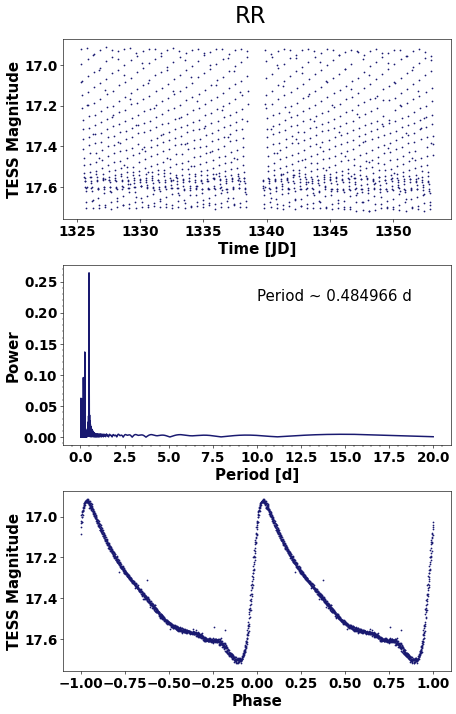

In [40]:
clean(RR1[147:148].reset_index(drop=True),'testtest','testingRR','sec1allcams',50,0)
;

147201138_sector01_1_1

In [195]:
for i in range(len(ED1)):
    if ED1['TIC_ID'][i] == '147201138':
        print(i)

25


In [27]:
clean(ED1[25:26].reset_index(drop=True),'testtest','testingED','sec1allcams',50,0)

/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(


220377888_sector01_2_4

In [146]:
for i in range(len(GDOR1)):
    if GDOR1['TIC_ID'][i] == '220377888':
        print(i)

9


In [28]:
clean(GDOR1[9:10].reset_index(drop=True),'testtest','testinggdor','sec1allcams',50,0)

/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(


In [16]:
#Using the 'magdiff' function on each of the type dataframes (This could have been done on the entire sector)
diffCST1 = magdiff(CST1)
diffMISC1 = magdiff(MISC1)
diffRR1 = magdiff(RR1)
diffEC1 = magdiff(EC1)
diffED1 = magdiff(ED1)
diffDSCT1 = magdiff(DSCT1)
diffDCEP1 = magdiff(DCEP1)
diffGDOR1 = magdiff(GDOR1)

In [17]:
#Example of cleaning each of the datasets with their corresponding CSV files from the "clean" function
#GDOR and CST were more complicated because I used the "clean" function on MISC a couple times to find more constant and gamma doradus stars that were within the MISC category

sec1cleanMISC = cleaneddata(diffMISC1,'MISC','MISCto999')
sec1cleanRR = cleaneddata(diffRR1,'RR','RRto999')
sec1cleanEC = cleaneddata(diffEC1,'EC','ECto999')
sec1cleanED = cleaneddata(diffED1,'ED','EDto999')
sec1cleanDSCT = cleaneddata(diffDSCT1,'DSCT','DSCT_all')
sec1cleanDCEP = cleaneddata(diffDCEP1,'DCEP','DCEPto999')

sec1cleanCST1 = cleaneddata(diffCST1,'CST','CST_all')
sec1cleanGDOR1 = cleaneddata(diffGDOR1,'GDOR','GDOR_all')

sec1cleanCST2 = cleaneddata(diffMISC1,'MISC','const_new')
sec1cleanGDOR2 = cleaneddata(diffMISC1,'MISC','GDOR_new')

for val in sec1cleanCST2.Type.unique():
        sec1cleanCST2.replace(to_replace=val, value='CST', inplace=True)

for val in sec1cleanGDOR2.Type.unique():
        sec1cleanGDOR2.replace(to_replace=val, value='GDOR', inplace=True)

sec1cleanGDOR = pd.concat([sec1cleanGDOR1, sec1cleanGDOR2])
sec1cleanGDOR = sec1cleanGDOR.reset_index()
sec1cleanGDOR = sec1cleanGDOR.drop('index',axis = 1)

sec1cleanCST = pd.concat([sec1cleanCST1, sec1cleanCST2])
sec1cleanCST = sec1cleanCST.reset_index()
sec1cleanCST = sec1cleanCST.drop('index',axis = 1)

In [16]:
sec1cleanCST

,0,_1,Type,TIC_ID,Sector,Camera,CCD,ra,dec,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE,VmKmag,w1mw4mag
0,yes,314.492633 -40.288267,CST,389527262,sector01,1,1,314.492633,-40.288267,6039.0,-0.31105,0.00038,3.91720197,49.06805,11.51238434,9.12735,1.352000,1.102000
1,yes,325.528817 -41.134712,CST,159858568,sector01,1,1,325.528817,-41.134712,3682.0,2.30495,0.00271,14.64895158,1010.70715,0.10420759,8.61805,4.034999,4.991000
2,yes,311.308397 -30.955672,CST,441419997,sector01,1,4,311.308397,-30.955672,6130.0,-0.13778,0.00031,14.59414789,149.49302,13.8644405,13.39624,1.297000,0.025000
3,yes,340.636357 -44.250312,CST,44565278,sector01,2,3,340.636357,-44.250312,4366.0,5.10758,0.0073,9.59775724,178.1375,13.916748,9.19268,2.779000,2.232000
4,yes,340.681442 -47.180054,CST,44577687,sector01,2,3,340.681442,-47.180054,5186.0,1.24233,0.01675,14.62736421,78.18818,13.895996,10.10106,1.950001,5.682000
5,yes,77.430196 -67.752488,CST,40339153,sector01,4,1,77.430196,-67.752488,3287.0,-0.20252,0.00341,16.37271647,99.86534,13.916809,10.09492,5.398000,1.102000
6,yes,81.938986 -65.093773,CST,149215124,sector01,4,1,81.938986,-65.093773,3759.0,0.00766,0.01313,9.27787267,37.28302,0.10409947,7.74119,3.888000,2.709000
7,yes,71.651537 -76.725368,CST,140608326,sector01,4,2,71.651537,-76.725368,5887.0,-0.29841,0.00057,11.133252,39.38907,13.916565,10.34018,1.596001,1.092000
8,yes,104.933072 -63.785117,CST,167811250,sector01,4,3,104.933072,-63.785117,5380.0,0.37508,0.0062,14.64901579,758.58715,13.916565,9.56175,2.037000,1.473000
9,yes,312.908065 -41.341475,CST,389475380,sector01,1,1,312.908065,-41.341475,2932.0,43.97405,0.02801,13.916504,1257.72272,0.10409945,8.77144,6.307000,0.706000


In [17]:
testsec1plot = pd.concat([sec1cleanMISC,sec1cleanRR,sec1cleanEC,sec1cleanED,sec1cleanDSCT,sec1cleanDCEP,sec1cleanCST,sec1cleanGDOR])
testsec1plot = testsec1plot.reset_index()
testsec1plot = testsec1plot.drop('index',axis = 1)
testsec1plot

,0,_1,Type,TIC_ID,Sector,Camera,CCD,ra,dec,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE,VmKmag,w1mw4mag
0,yes,312.908065 -41.341475,MISC,389475380,sector01,1,1,312.908065,-41.341475,2932.0,43.97405,0.02801,13.916504,1257.72272,0.10409945,8.77144,6.307000,0.706
1,yes,325.888097 -43.14454,MISC,147335949,sector01,1,1,325.888097,-43.14454,3070.0,30.66852,0.0231,11.59708667,2427.2134,0.10409945,7.5651,5.871000,0.306
2,yes,322.923138 -46.113605,MISC,147198074,sector01,1,1,322.923138,-46.113605,3339.0,19.08789,0.01615,11.1332032,854.18351,13.01386874,9.1758,5.076000,0.179
3,yes,320.863403 -46.666603,MISC,200655862,sector01,1,1,320.863403,-46.666603,3268.0,12.60208,0.01249,11.59708667,1868.85119,13.01386874,11.52001,5.491000,0.384
4,yes,323.404587 -39.046575,MISC,382222583,sector01,1,1,323.404587,-39.046575,3827.0,10.08912,0.01071,11.0832032,1736.24946,0.10425821,7.60141,3.695000,0.220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2046,yes,317.252913 -58.332711,GDOR,220377891,sector01,2,4,317.252913,-58.332711,6983.0,3.1612,0.00535,1.06232855,978.00326,3.16383782,7.5368,1.470000,0.061
2047,yes,317.269335 -58.326367,GDOR,220377888,sector01,2,4,317.269335,-58.326367,5582.0,3.2137,0.00554,1.06232855,870.32509,4.23140269,7.35875,1.611000,2.423
2048,yes,123.444473 -68.651352,GDOR,307084879,sector01,4,3,123.444473,-68.651352,7016.0,0.9563,0.00322,1.00119173,674.86712,1.00112539,7.93444,1.066000,-0.017
2049,yes,330.59941 -31.502263,GDOR,80080217,sector01,1,2,330.59941,-31.502263,5460.0,-0.0507,0.00765,14.64927263,435.49318,13.916809,10.34483,1.785000,4.210


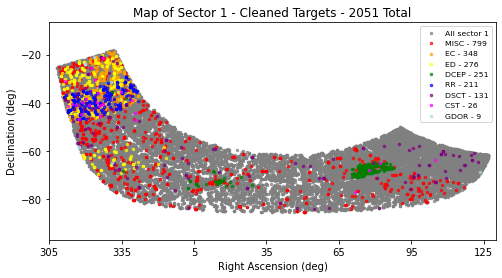

In [45]:
def wrap_ra(ra_series):
    ra = pd.to_numeric(ra_series)
    return np.where(ra < 300, ra + 360, ra)

plt.figure(figsize=(8, 4))

plt.scatter(wrap_ra(Sector1['ra']), pd.to_numeric(Sector1['dec']), color='grey', alpha=0.7, s=6, label='All sector 1')
plt.scatter(wrap_ra(sec1cleanMISC['ra']), pd.to_numeric(sec1cleanMISC['dec']), color='red', alpha=0.7, s=6, label='MISC - 799')
plt.scatter(wrap_ra(sec1cleanEC['ra']), pd.to_numeric(sec1cleanEC['dec']), color='orange', alpha=0.7, s=6, label='EC - 348')
plt.scatter(wrap_ra(sec1cleanED['ra']), pd.to_numeric(sec1cleanED['dec']), color='yellow', alpha=0.7, s=6, label='ED - 276')
plt.scatter(wrap_ra(sec1cleanDCEP['ra']), pd.to_numeric(sec1cleanDCEP['dec']), color='green', alpha=0.7, s=6, label='DCEP - 251')
plt.scatter(wrap_ra(sec1cleanRR['ra']), pd.to_numeric(sec1cleanRR['dec']), color='blue', alpha=0.7, s=6, label='RR - 211')
plt.scatter(wrap_ra(sec1cleanDSCT['ra']), pd.to_numeric(sec1cleanDSCT['dec']), color='purple', alpha=0.7, s=6, label='DSCT - 131')
plt.scatter(wrap_ra(sec1cleanCST['ra']), pd.to_numeric(sec1cleanCST['dec']), color='magenta', alpha=0.7, s=6, label='CST - 26')
plt.scatter(wrap_ra(sec1cleanGDOR['ra']), pd.to_numeric(sec1cleanGDOR['dec']), color='lightblue', alpha=0.7, s=6, label='GDOR - 9')

plt.axis('equal') 
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title('Map of Sector 1 - Cleaned Targets - 2051 Total')
plt.legend(loc = 'upper right', fontsize=7.8)

plt.xlim(490, 305)
plt.gca().invert_xaxis()

tick_locs = np.arange(305, 491, 30)
tick_labels = [str(t if t < 360 else t - 360) for t in tick_locs]
plt.xticks(tick_locs, tick_labels)

plt.savefig("sec1targets.png", dpi=300, bbox_inches='tight',facecolor='white')

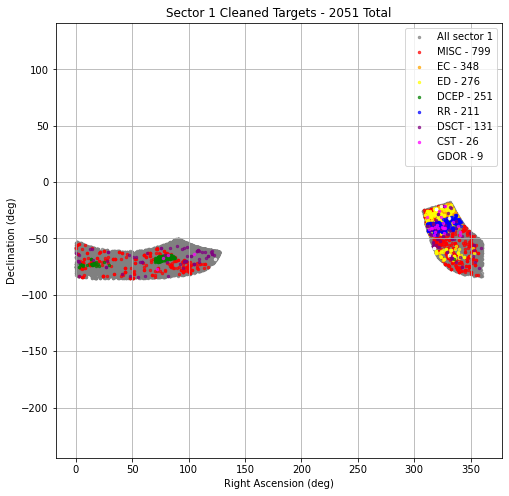

In [206]:
plt.figure(figsize=(8, 8))
plt.scatter(pd.to_numeric(Sector1['ra']), pd.to_numeric(Sector1['dec']), color='grey',alpha=0.7,s=6,label = 'All sector 1')
plt.scatter(pd.to_numeric(sec1cleanMISC['ra']), pd.to_numeric(sec1cleanMISC['dec']), color='red',alpha=0.7,s=6,label = 'MISC - 799')
plt.scatter(pd.to_numeric(sec1cleanEC['ra']), pd.to_numeric(sec1cleanEC['dec']), color='orange',alpha=0.7,s=6,label = 'EC - 348')
plt.scatter(pd.to_numeric(sec1cleanED['ra']), pd.to_numeric(sec1cleanED['dec']), color='yellow',alpha=0.7,s=6,label = 'ED - 276')
plt.scatter(pd.to_numeric(sec1cleanDCEP['ra']), pd.to_numeric(sec1cleanDCEP['dec']), color='green',alpha=0.7,s=6,label = 'DCEP - 251')
plt.scatter(pd.to_numeric(sec1cleanRR['ra']), pd.to_numeric(sec1cleanRR['dec']), color='blue',alpha=0.7,s=6,label = 'RR - 211')
plt.scatter(pd.to_numeric(sec1cleanDSCT['ra']), pd.to_numeric(sec1cleanDSCT['dec']), color='purple',alpha=0.7,s=6,label = 'DSCT - 131')
plt.scatter(pd.to_numeric(sec1cleanCST['ra']), pd.to_numeric(sec1cleanCST['dec']), color='magenta',alpha=0.7,s=6,label = 'CST - 26')
plt.scatter(pd.to_numeric(sec1cleanGDOR['ra']), pd.to_numeric(sec1cleanGDOR['dec']), color='white',alpha=0.7,s=6,label = 'GDOR - 9')

plt.axis('equal') 
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title('Sector 1 Cleaned Targets - 2051 Total')
plt.grid(True)
plt.legend()



/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:613: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a posit

KeyboardInterrupt: 

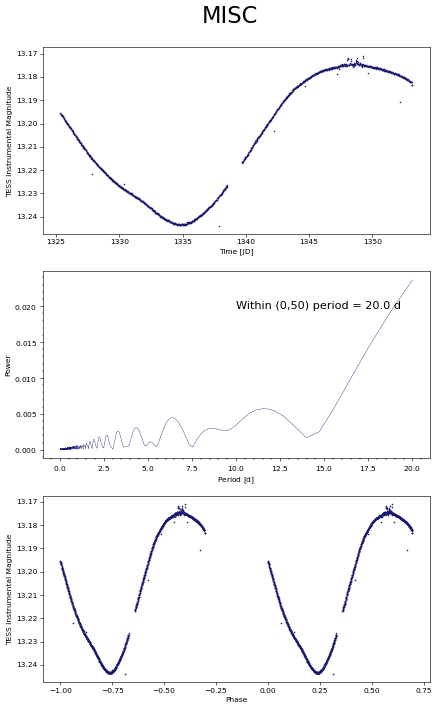

In [187]:
clean(MISC1,'testtest','testingMISC','sec1allcams',50,0)

/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a positional argument is deprecated, please use ``flux=...`` instead.
  warnings.warn(
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:613: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/lightkurve/lightcurve.py:279: LightkurveDeprecationWarning: passing flux as a posit

KeyboardInterrupt: 

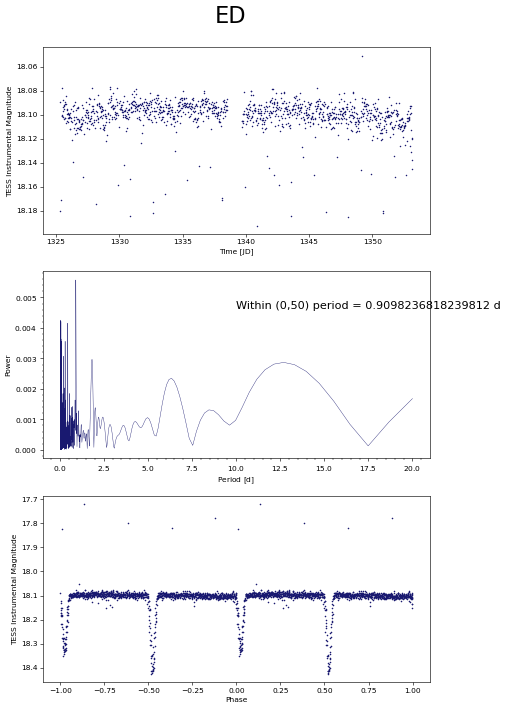

In [144]:
clean(sec1cleanED,'testtest','testingED','sec1allcams',50,0)

In [18]:
#Creating a mixed dataset of all the types concatenated to use for machine learning
clean_sec1 = pd.concat([sec1cleanGDOR,sec1cleanDCEP,sec1cleanDSCT,sec1cleanED,sec1cleanRR,sec1cleanEC,sec1cleanMISC,sec1cleanCST])
clean_sec1 = clean_sec1.reset_index()
clean_sec1 = clean_sec1.drop('index',axis = 1)
clean_sec1

clean_sec1_mix = clean_sec1.sample(frac = 1)

sec1_cleaned_ml = clean_sec1_mix[['Type','Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag']]
sec1_cleaned_ml.to_csv('sec1_cleaned_ml.csv', index=False)

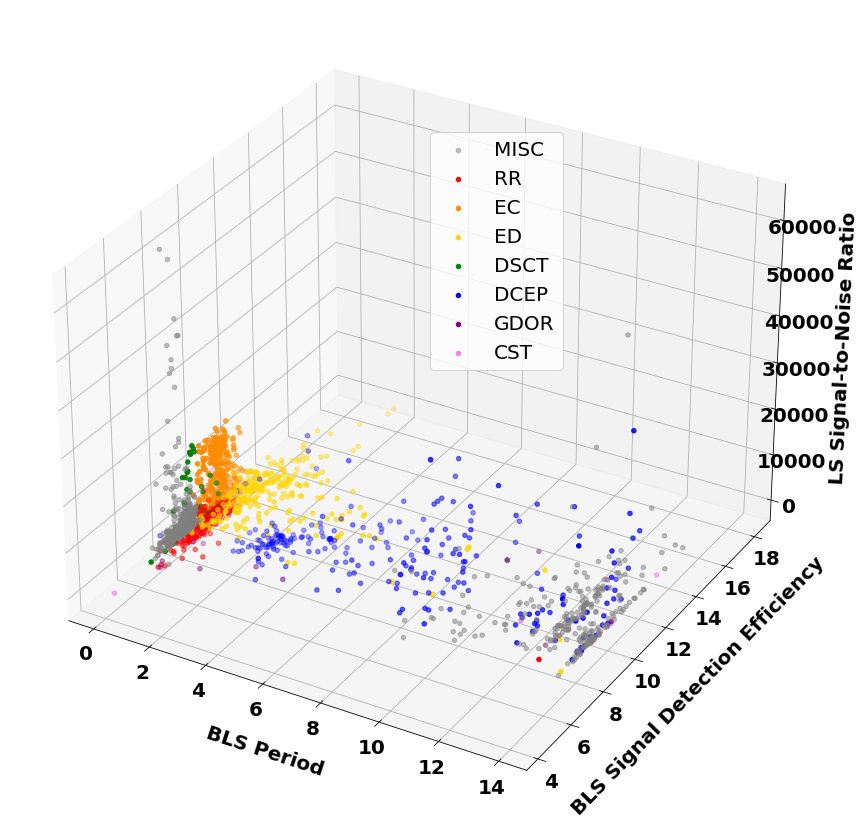

In [175]:
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(projection='3d')

ax.scatter(pd.to_numeric(sec1cleanMISC['BLS_Period']), pd.to_numeric(sec1cleanMISC['BLS_SDE']), pd.to_numeric(sec1cleanMISC['LS_SNR']), marker = 'o', alpha=0.5, label = 'MISC', color = 'gray')
ax.scatter(pd.to_numeric(sec1cleanRR['BLS_Period']), pd.to_numeric(sec1cleanRR['BLS_SDE']), pd.to_numeric(sec1cleanRR['LS_SNR']), marker = 'o', label = 'RR', color = 'red')
ax.scatter(pd.to_numeric(sec1cleanEC['BLS_Period']), pd.to_numeric(sec1cleanEC['BLS_SDE']), pd.to_numeric(sec1cleanEC['LS_SNR']), marker = 'o', label = 'EC', color = 'darkorange')
ax.scatter(pd.to_numeric(sec1cleanED['BLS_Period']), pd.to_numeric(sec1cleanED['BLS_SDE']), pd.to_numeric(sec1cleanED['LS_SNR']), marker = 'o', label = 'ED', color = 'gold')
ax.scatter(pd.to_numeric(sec1cleanDSCT['BLS_Period']), pd.to_numeric(sec1cleanDSCT['BLS_SDE']), pd.to_numeric(sec1cleanDSCT['LS_SNR']), marker = 'o', label = 'DSCT', color = 'green')
ax.scatter(pd.to_numeric(sec1cleanDCEP['BLS_Period']), pd.to_numeric(sec1cleanDCEP['BLS_SDE']), pd.to_numeric(sec1cleanDCEP['LS_SNR']), marker = 'o', label = 'DCEP',color = 'blue')
ax.scatter(pd.to_numeric(sec1cleanGDOR['BLS_Period']), pd.to_numeric(sec1cleanGDOR['BLS_SDE']), pd.to_numeric(sec1cleanGDOR['LS_SNR']), marker = 'o', label = 'GDOR', color = 'purple')
ax.scatter(pd.to_numeric(sec1cleanCST['BLS_Period']), pd.to_numeric(sec1cleanCST['BLS_SDE']), pd.to_numeric(sec1cleanCST['LS_SNR']), marker = 'o', label = 'CST', color = 'violet')

ax.legend(loc='center', bbox_to_anchor=(0.6, 0.70),fontsize=20,frameon=True)

ax.set_xlabel('BLS Period', fontsize=20, fontweight='bold', labelpad=20)
ax.set_ylabel('BLS Signal Detection Efficiency', fontsize=20, fontweight='bold', labelpad=20)
ax.set_zlabel('LS Signal-to-Noise Ratio', fontsize=20, fontweight='bold', labelpad=20)

ax.tick_params(labelsize=20) 

for tick in ax.get_xticklabels() + ax.get_yticklabels() + ax.get_zticklabels():
    tick.set_fontweight('bold')

plt.savefig("3dplot.png", dpi=300, bbox_inches='tight',facecolor='white')

In [19]:
sec1_ml = pd.read_csv('sec1_cleaned_ml.csv')
sec1_ml

,Type,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE,VmKmag,w1mw4mag
0,MISC,2824.0,24.54821,0.03693,13.253813,3213.49912,0.104099,8.22046,6.816999,0.676
1,RR,7140.0,19.93179,0.20910,0.484896,3349.26893,0.485328,7.17384,0.716001,3.220
2,MISC,2764.0,13.07764,0.02198,13.916503,1118.95294,0.104099,8.60182,7.085999,1.268
3,DSCT,7027.0,7.17917,0.05261,0.144587,13078.23654,0.144616,8.46914,1.099000,3.536
4,MISC,5101.0,28.36983,0.03488,9.277669,378.16386,0.104099,8.55862,2.252001,4.081
...,...,...,...,...,...,...,...,...,...,...
2046,MISC,3496.0,10.81486,0.04130,14.648951,2815.66389,0.104099,8.43521,4.568000,0.367
2047,MISC,5869.0,1.04573,0.00960,25.283757,916.64616,13.004741,8.81121,1.729000,2.976
2048,MISC,3601.0,5.59319,0.03057,14.649016,2560.62432,0.104099,8.13201,4.251000,1.420
2049,EC,4277.0,0.28823,0.00918,0.179336,1459.66853,0.358664,9.59539,2.997000,3.524


In [21]:
#Example of how the 'bestcols' function works
cols = ['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag']

bestcols(sec1_ml,cols,RandomForestClassifier(random_state=20,n_estimators=50),3,False)

0.8947368421052632 ['LS_Period', 'BLS_Period']
0.9239766081871345 ['BLS_Period', 'BLS_SDE', 'LS_Period']
0.9317738791423001 All columns
Duration: 0:00:42.109206


In [39]:
#Creating the variable for a random forest classifier to use for 'resulttypes' function later on
X = sec1_ml.drop('Type',axis = 1)
X = X.apply(pd.to_numeric)
Y = sec1_ml['Type']
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3, train_size=0.7)

forest = RandomForestClassifier(random_state=20, max_depth = 10, min_samples_split=10, n_estimators = 250)
forest.fit(X_train, y_train)

ypredfor = forest.predict(X_test)

score = metrics.accuracy_score(y_test, ypredfor)

score


0.9237012987012987

In [312]:
ests = np.arange(1,300,1)
accuracy = []
for val in ests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, ypredfor))


In [86]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

101
0.952922077922078
102


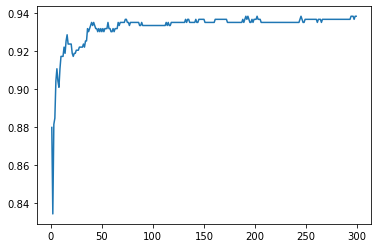

In [39]:
plt.plot(ests,accuracy)

In [41]:
ests = np.arange(1,100,1)
accuracy = []
for val in ests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, ypredfor))

In [42]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

72
0.9366883116883117
73


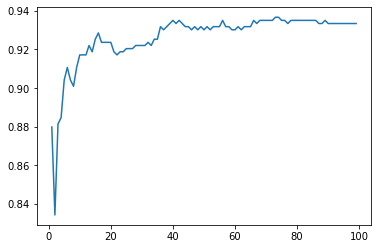

In [43]:
plt.plot(ests,accuracy)

In [45]:
forest_test = RandomForestClassifier(random_state=20, n_estimators = 73)
forest_test.fit(X_train, y_train)
ypredfor = forest_test.predict(X_test)
print(metrics.accuracy_score(y_test, ypredfor))

0.9366883116883117


In [46]:
ests = np.arange(1,100,1)
accuracy = []
for val in ests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 73, max_depth = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, ypredfor))

In [47]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

7
0.939935064935065
8


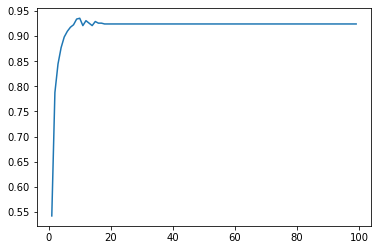

In [23]:
plt.plot(ests,accuracy)

In [217]:
nests = np.arange(1,100,1)
accuracy1 = []
for val in nests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy1.append(metrics.accuracy_score(y_test, ypredfor))

In [218]:
mdep = np.arange(1,100,1)
accuracy2 = []
for val in mdep:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 48, max_depth = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy2.append(metrics.accuracy_score(y_test, ypredfor))

In [219]:
samsp = np.arange(2,100,1)
accuracy3 = []
for val in samsp:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 48, max_depth = 12, min_samples_split=val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy3.append(metrics.accuracy_score(y_test, ypredfor))

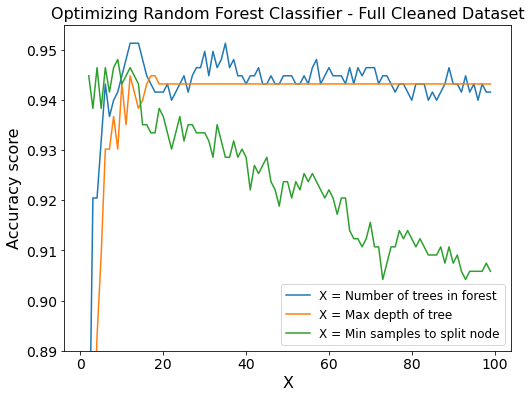

In [228]:
plt.figure(figsize=(8, 6))
plt.plot(nests,accuracy1,label = "X = Number of trees in forest")
plt.plot(mdep,accuracy2, label = 'X = Max depth of tree')
plt.plot(samsp,accuracy3,label = 'X = Min samples to split node')
plt.xlabel('X', fontsize=16)
plt.ylabel('Accuracy score', fontsize=16)
plt.title('Optimizing Random Forest Classifier - Full Cleaned Dataset', fontsize=16)
plt.legend(loc='lower right',fontsize=12)
plt.ylim(0.89, 0.955)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.savefig("opt_full.png", dpi=300, bbox_inches='tight',facecolor='white')

In [49]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

0
0.939935064935065
2


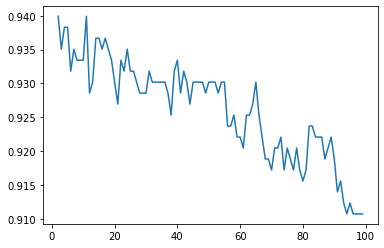

In [50]:
plt.plot(ests,accuracy)

In [205]:

nest = np.arange(1,100,1)
mss = np.arange(2,20,1)
accuracy = []
for n in nest:
    for o in mss:
        forest_test = RandomForestClassifier(random_state=20, n_estimators = n, max_depth = 8, min_samples_split=o)
        forest_test.fit(X_train, y_train)
        ypredfor = forest_test.predict(X_test)
        accuracy.append([metrics.accuracy_score(y_test, ypredfor),n,o])

KeyboardInterrupt: 

In [324]:
print(max(sublist[0] for sublist in accuracy))
print(next(i for i, sublist in enumerate(accuracy) if sublist[0] == max(sublist[0] for sublist in accuracy)))
print(accuracy[next(i for i, sublist in enumerate(accuracy) if sublist[0] == max(sublist[0] for sublist in accuracy))])


0.9512987012987013
490
[0.9512987012987013, 28, 6]


In [215]:
nest = np.arange(1,50,1)
md = np.arange(1,20,1)
mss = np.arange(2,20,1)
accuracy = []
for n in nest:
    for o in md:
        for p in mss:
            forest_test = RandomForestClassifier(random_state=20, n_estimators = n, max_depth = o, min_samples_split=p)
            forest_test.fit(X_train, y_train)
            ypredfor = forest_test.predict(X_test)
            accuracy.append([metrics.accuracy_score(y_test, ypredfor),n,o,p])

In [216]:
print(max(sublist[0] for sublist in accuracy))
print(next(i for i, sublist in enumerate(accuracy) if sublist[0] == max(sublist[0] for sublist in accuracy)))
print(accuracy[next(i for i, sublist in enumerate(accuracy) if sublist[0] == max(sublist[0] for sublist in accuracy))])

0.952922077922078
3294
[0.952922077922078, 10, 13, 2]


In [250]:
forest_test = RandomForestClassifier(random_state=20)
forest_test.fit(X_train, y_train)
ypredfor = forest_test.predict(X_test)
print(metrics.accuracy_score(y_test, ypredfor))

0.9464285714285714


In [252]:
print('RandomForestClassifier')
print('accuracy score :', accuracy_score(y_test, ypredfor))
print('precision :', precision_score(y_test, ypredfor, average='weighted'))
print('recall :', recall_score(y_test, ypredfor, average='weighted'))
print('f1 :', f1_score(y_test, ypredfor, average='weighted'))

RandomForestClassifier
accuracy score : 0.9464285714285714
precision : 0.9424260076773416
recall : 0.9464285714285714
f1 : 0.9440431264734062


/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [264]:
knn_test = KNeighborsClassifier(n_neighbors=10)
knn_test.fit(X_train, y_train)
ypredknn = knn_test.predict(X_test)
print(metrics.accuracy_score(y_test, ypredknn))

0.5194805194805194


In [262]:
print('KNeighborsClassifier')
print('accuracy score :', accuracy_score(y_test, ypredknn))
print('precision :', precision_score(y_test, ypredknn, average='weighted'))
print('recall :', recall_score(y_test, ypredknn, average='weighted'))
print('f1 :', f1_score(y_test, ypredknn, average='weighted'))

KNeighborsClassifier
accuracy score : 0.5194805194805194
precision : 0.4997061786423615
recall : 0.5194805194805194
f1 : 0.502021711477671


/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:

mlp_test = MLPClassifier()
mlp_test.fit(X_train, y_train)
ypredmlp = mlp_test.predict(X_test)
print(metrics.accuracy_score(y_test, ypredmlp))

0.6298701298701299


In [41]:
print('MLPClassifier')
print('accuracy score :', accuracy_score(y_test, ypredmlp))
print('precision :', precision_score(y_test, ypredmlp, average='weighted'))
print('recall :', recall_score(y_test, ypredmlp, average='weighted'))
print('f1 :', f1_score(y_test, ypredmlp, average='weighted'))

MLPClassifier
accuracy score : 0.6298701298701299
precision : 0.5831201451831186
recall : 0.6298701298701299
f1 : 0.5718755913729984


/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [275]:
KMeans_test = KMeans(n_clusters = 2)
KMeans_test.fit(X_train, y_train)
ypredKMeans = KMeans_test.fit_predict(X_test)

print('KMeans')
print('silhouette score :', silhouette_score(X_test, ypredKMeans))


KMeans
silhouette score : 0.7422241549656905


In [276]:
from sklearn.metrics import homogeneity_score, completeness_score
print('KMeans')
print('silhouette score :', silhouette_score(X_test, ypredKMeans))
print("Homogeneity score:", homogeneity_score(y_test, ypredKMeans))
print("Completeness score:", completeness_score(y_test, ypredKMeans))

KMeans
silhouette score : 0.7422241549656905
Homogeneity score: 0.046632969817331706
Completeness score: 0.1976209622717705


Labels: ['CST' 'DCEP' 'DSCT' 'EC' 'ED' 'GDOR' 'MISC' 'RR']


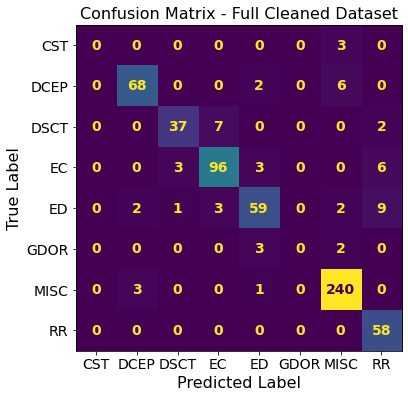

In [235]:
labels = np.unique(y_test)
print("Labels:", labels)

cm = confusion_matrix(y_test, ypredfor)

fig, ax = plt.subplots(figsize=(8, 6)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax,colorbar=False)

ax.set_title('Confusion Matrix - Full Cleaned Dataset', fontsize=16)
ax.set_xlabel('Predicted Label', fontsize=16)
ax.set_ylabel('True Label', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

for text in ax.texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

plt.savefig("mat_full.png", dpi=300, bbox_inches='tight',facecolor='white')
plt.show()


In [330]:
#Checking the classifier's confusion matrix
metrics.confusion_matrix(y_test, ypredfor)

array([[  0,   0,   1,   1,   0,   0,   7,   0],
       [  0,  70,   0,   0,   0,   0,   2,   0],
       [  0,   0,  37,   0,   0,   0,   0,   0],
       [  0,   0,   0,  93,   0,   0,   0,   0],
       [  0,   1,   1,   4,  72,   0,   0,   4],
       [  0,   0,   0,   0,   1,   0,   0,   1],
       [  0,   0,   0,   1,   0,   0, 255,   0],
       [  0,   0,   0,   0,   0,   0,   0,  65]])

In [65]:
forest_test = RandomForestClassifier(random_state=70, n_estimators = 75, max_depth = 10, min_samples_split=13)
forest_test.fit(X_train, y_train)
ypredfor = forest_test.predict(X_test)
print(metrics.accuracy_score(y_test, ypredfor))
metrics.confusion_matrix(y_test, ypredfor)

0.9366883116883117


array([[  0,   0,   1,   0,   0,   0,   8,   0],
       [  0,  74,   0,   0,   1,   0,   0,   0],
       [  0,   0,  33,   3,   0,   0,   0,   0],
       [  0,   0,   3,  92,   2,   0,   0,   3],
       [  0,   1,   1,   3,  74,   0,   0,   4],
       [  0,   0,   0,   0,   0,   0,   1,   3],
       [  0,   2,   0,   0,   0,   0, 251,   0],
       [  0,   0,   0,   1,   1,   0,   1,  53]])

In [20]:
MISC_1,CST_1,RR_1,EC_1,ED_1,DSCT_1,DCEP_1,GDOR_1 = septypes(sec1_ml)

In [21]:
print(len(MISC_1))
print(len(CST_1))
print(len(RR_1))
print(len(EC_1))
print(len(ED_1))
print(len(DSCT_1))
print(len(DCEP_1))
print(len(GDOR_1))

799
26
211
348
276
131
251
9


In [22]:
MISC_sam = MISC_1.sample(n=50)
RR_sam = RR_1.sample(n=50)
EC_sam = EC_1.sample(n=50)
ED_sam = ED_1.sample(n=50)
DSCT_sam = DSCT_1.sample(n=50)
DCEP_sam = DCEP_1.sample(n=50)


In [23]:
clean_sec1_sam = pd.concat([GDOR_1,DCEP_sam,DSCT_sam,ED_sam,RR_sam,EC_sam,MISC_sam,CST_1])
clean_sec1_sam = clean_sec1_sam.reset_index()
clean_sec1_sam = clean_sec1_sam.drop('index',axis = 1)
clean_sec1_sam

clean_sec1_sam_mix = clean_sec1_sam.sample(frac = 1)

clean_sec1_sam_mix.to_csv('sec1_sample_ml.csv', index=False)

In [24]:
sec1_sam_ml = pd.read_csv('sec1_sample_ml.csv')
sec1_sam_ml

,Type,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE,VmKmag,w1mw4mag
0,RR,4696.0,5.72424,0.05885,0.479879,2603.24112,0.479528,7.66098,2.379000,3.576000
1,GDOR,5460.0,-0.05070,0.00765,14.649273,435.49318,13.916809,10.34483,1.785000,4.210000
2,RR,6448.0,0.28468,0.00538,0.484896,1094.77374,0.485328,8.32695,1.037000,2.672999
3,MISC,3208.0,25.27547,0.02021,14.649016,2503.32609,0.104099,8.28748,5.708000,0.388000
4,EC,6558.0,18.07307,0.05171,0.554455,9906.41667,0.553625,9.47305,1.078000,0.870000
...,...,...,...,...,...,...,...,...,...,...
330,MISC,4514.0,9.58478,0.01579,12.101573,1580.51735,13.014135,9.56498,2.589000,-0.048000
331,DCEP,4634.0,0.40831,0.00537,4.638936,1557.26779,13.916809,9.78862,2.447000,0.406000
332,EC,4309.0,1.31075,0.01713,0.122775,9106.09845,0.122761,10.09026,2.950000,4.019000
333,RR,5307.0,-0.05910,0.00592,0.474720,487.05438,0.948893,7.55858,1.842999,3.551001


In [131]:
X = sec1_sam_ml.drop('Type',axis = 1)
X = X.apply(pd.to_numeric)
Y = sec1_sam_ml['Type']
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3, train_size=0.7)

forest_test = RandomForestClassifier(random_state=20)
forest_test.fit(X_train, y_train)
ypredfor = forest_test.predict(X_test)

metrics.accuracy_score(y_test, ypredfor)

0.8613861386138614

In [298]:
ests = np.arange(1,200,1)
accuracy = []
for val in ests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, ypredfor))

In [42]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

13
0.8910891089108911
14


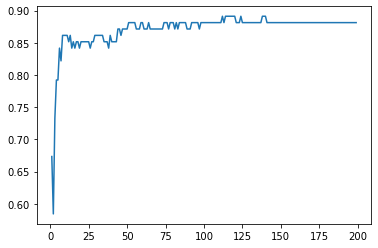

In [263]:
plt.plot(ests,accuracy)

In [264]:
ests = np.arange(1,100,1)
accuracy = []
for val in ests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 30, max_depth = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, ypredfor))

In [265]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

5
0.8910891089108911
6


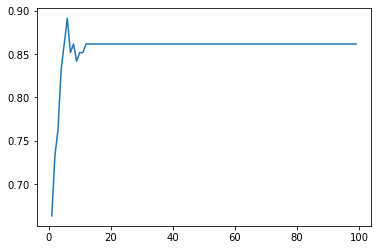

In [266]:
plt.plot(ests,accuracy)

In [267]:
ests = np.arange(2,100,1)
accuracy = []
for val in ests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 73, max_depth = 8, min_samples_split=val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy.append(metrics.accuracy_score(y_test, ypredfor))

In [268]:
print(accuracy.index(max(accuracy)))
print(accuracy[accuracy.index(max(accuracy))])
print(ests[accuracy.index(max(accuracy))])

0
0.8910891089108911
2


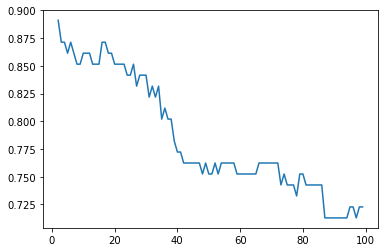

In [269]:
plt.plot(ests,accuracy)

In [132]:
nest = np.arange(1,50,1)
md = np.arange(1,20,1)
mss = np.arange(2,20,1)
accuracy = []
for n in nest:
    for o in md:
        for p in mss:
            forest_test = RandomForestClassifier(random_state=20, n_estimators = n, max_depth = o, min_samples_split=p)
            forest_test.fit(X_train, y_train)
            ypredfor = forest_test.predict(X_test)
            accuracy.append([metrics.accuracy_score(y_test, ypredfor),n,o,p])

In [133]:
print(max(sublist[0] for sublist in accuracy))
print(next(i for i, sublist in enumerate(accuracy) if sublist[0] == max(sublist[0] for sublist in accuracy)))
print(accuracy[next(i for i, sublist in enumerate(accuracy) if sublist[0] == max(sublist[0] for sublist in accuracy))])

0.8811881188118812
5587
[0.8811881188118812, 17, 7, 9]


In [281]:
forest_test = RandomForestClassifier(random_state=20, n_estimators = 12, max_depth = 10, min_samples_split=4)
forest_test.fit(X_train, y_train)
ypredfor = forest_test.predict(X_test)
print(metrics.accuracy_score(y_test, ypredfor))

0.8910891089108911


In [37]:
print('RandomForestClassifier - Sampled & Optimized')
print('accuracy score :', accuracy_score(y_test, ypredfor))
print('precision :', precision_score(y_test, ypredfor, average='weighted'))
print('recall :', recall_score(y_test, ypredfor, average='weighted'))
print('f1 :', f1_score(y_test, ypredfor, average='weighted'))

RandomForestClassifier - Sampled & Optimized
accuracy score : 0.9108910891089109
precision : 0.8906293106090795
recall : 0.9108910891089109
f1 : 0.8953232823282329


In [38]:
metrics.confusion_matrix(y_test, ypredfor)

array([[ 0,  0,  1,  0,  0,  0,  4,  0],
       [ 0, 16,  0,  0,  0,  0,  1,  0],
       [ 0,  0, 16,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 11,  0,  0,  0,  0],
       [ 0,  1,  0,  0, 19,  0,  1,  0],
       [ 1,  0,  0,  0,  0,  2,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 13,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 15]])

In [184]:
labels = np.unique(y_test)
print("Labels:", labels)

Labels: ['CST' 'DCEP' 'DSCT' 'EC' 'ED' 'GDOR' 'MISC' 'RR']


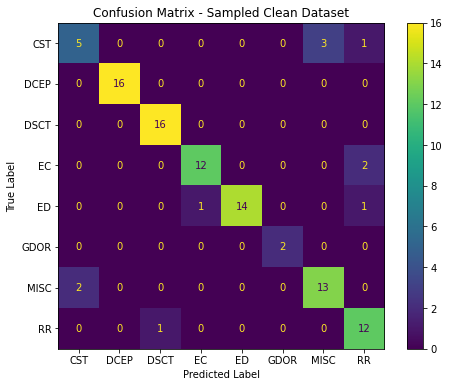

In [282]:
cm = confusion_matrix(y_test, ypredfor)

fig, ax = plt.subplots(figsize=(8, 6)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax)

plt.title('Confusion Matrix - Sampled Clean Dataset')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("mat_sampled.png", dpi=300, bbox_inches='tight',facecolor='white')
plt.show()

Labels: ['CST' 'DCEP' 'DSCT' 'EC' 'ED' 'GDOR' 'MISC' 'RR']


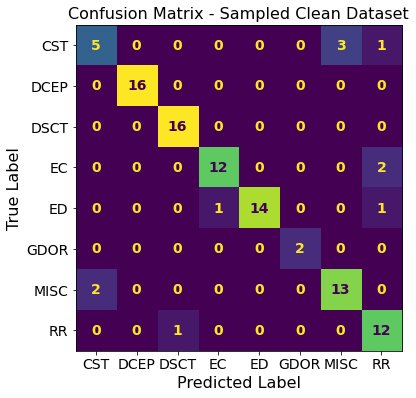

: 

In [285]:
labels = np.unique(y_test)
print("Labels:", labels)

cm = confusion_matrix(y_test, ypredfor)

fig, ax = plt.subplots(figsize=(8, 6)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax,colorbar=False)

ax.set_title('Confusion Matrix - Sampled Clean Dataset', fontsize=16)
ax.set_xlabel('Predicted Label', fontsize=16)
ax.set_ylabel('True Label', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

for text in ax.texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

plt.savefig("mat_sampled.png", dpi=300, bbox_inches='tight',facecolor='white')
plt.show()

In [145]:
nests = np.arange(1,100,1)
accuracy1 = []
for val in nests:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy1.append(metrics.accuracy_score(y_test, ypredfor))

In [146]:
mdep = np.arange(1,100,1)
accuracy2 = []
for val in mdep:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 73, max_depth = val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy2.append(metrics.accuracy_score(y_test, ypredfor))

In [147]:
samsp = np.arange(2,100,1)
accuracy3 = []
for val in samsp:
    forest_test = RandomForestClassifier(random_state=20, n_estimators = 73, max_depth = 8, min_samples_split=val)
    forest_test.fit(X_train, y_train)
    ypredfor = forest_test.predict(X_test)
    accuracy3.append(metrics.accuracy_score(y_test, ypredfor))

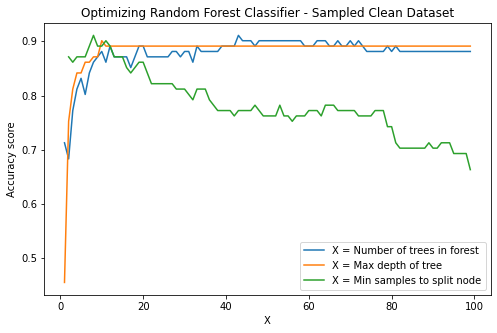

In [148]:
plt.figure(figsize=(8, 5))
plt.plot(nests,accuracy1,label = "X = Number of trees in forest")
plt.plot(mdep,accuracy2, label = 'X = Max depth of tree')
plt.plot(samsp,accuracy3,label = 'X = Min samples to split node')
plt.ylabel('Accuracy score')
plt.xlabel('X')
plt.title('Optimizing Random Forest Classifier - Sampled Clean Dataset')
plt.legend()
plt.savefig("opt_sampled.png", dpi=300, bbox_inches='tight',facecolor='white')


MISC1,CST1,RR1,EC1,ED1,DSCT1,DCEP1,GDOR1

In [ ]:
['Type','Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag']

In [85]:
miscresult = resulttypes(diffMISC1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])

In [86]:
total = 0
accurate = 0

for i in range(len(miscresult)):
    if miscresult['PredType'][i] == miscresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

1448
1004
0.6933701657458563


In [87]:
cstresult = resulttypes(diffCST1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])

In [88]:
total = 0
accurate = 0

for i in range(len(cstresult)):
    if cstresult['PredType'][i] == cstresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

43
25
0.5813953488372093


In [89]:
rrresult = resulttypes(diffRR1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])


In [90]:
total = 0
accurate = 0

for i in range(len(rrresult)):
    if rrresult['PredType'][i] == rrresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

7357
2358
0.3205110778850075


In [91]:
ECresult = resulttypes(diffEC1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])


In [92]:
total = 0
accurate = 0

for i in range(len(ECresult)):
    if ECresult['PredType'][i] == ECresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

7041
3066
0.43544951001278226


In [93]:
EDresult = resulttypes(diffED1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])

In [94]:
total = 0
accurate = 0

for i in range(len(EDresult)):
    if EDresult['PredType'][i] == EDresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

4321
1533
0.3547789863457533


In [95]:
DSCTresult = resulttypes(diffDSCT1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])

In [96]:
total = 0
accurate = 0

for i in range(len(DSCTresult)):
    if DSCTresult['PredType'][i] == DSCTresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

670
309
0.46119402985074626


In [98]:
DCEPresult = resulttypes(diffDCEP1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])

In [99]:
total = 0
accurate = 0

for i in range(len(DCEPresult)):
    if DCEPresult['PredType'][i] == DCEPresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

1778
773
0.4347581552305962


In [100]:
gdorresult = resulttypes(diffDCEP1,forest_test,['Teff','Jstet','RMS_60m','LS_Period','LS_SNR','BLS_Period','BLS_SDE','VmKmag','w1mw4mag'])

In [101]:
total = 0
accurate = 0

for i in range(len(gdorresult)):
    if gdorresult['PredType'][i] == gdorresult['Type'][i]:
        accurate += 1
    total += 1

print(total)
print(accurate)
print(accurate/total)

1778
773
0.4347581552305962


# Start here!

In [31]:
sec1_ml_full = pd.read_csv('sec1_cleaned_ml.csv')
sec1_ml_full

,Type,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE,VmKmag,w1mw4mag
0,RR,6663.0,12.11900,0.11271,0.551161,3267.49657,0.552101,9.22926,1.427000,3.335000
1,ED,5951.0,0.82815,0.00885,0.387116,237.52282,0.773438,9.63758,1.439000,1.528000
2,DSCT,4673.0,-0.69531,0.00811,7.731561,75.80068,0.122536,7.56785,2.480000,5.805000
3,MISC,4517.0,9.03528,0.06465,14.649016,2658.61422,0.104099,8.27005,2.585000,1.839001
4,ED,6350.0,-0.25618,0.00143,4.154180,23.22487,2.038691,15.48442,1.284000,3.545000
...,...,...,...,...,...,...,...,...,...,...
2046,RR,5284.0,0.79043,0.03705,0.583501,776.35232,0.582558,10.18584,1.863000,5.915000
2047,DSCT,6633.0,5.52017,0.01404,0.168481,17927.55624,0.168549,8.72230,1.393000,0.010000
2048,ED,5839.0,-0.04696,0.00391,1.024742,202.45299,1.026570,13.99491,1.585999,2.565001
2049,DCEP,5540.0,0.57751,0.00775,2.174454,597.95428,13.013869,9.80834,1.696000,3.582000


In [38]:
X = sec1_ml_full.drop('Type',axis = 1)
X = X.apply(pd.to_numeric)
Y = sec1_ml_full['Type']
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3, train_size=0.7)

forest_sec1 = RandomForestClassifier(random_state=20, n_estimators = 75, max_depth = 10, min_samples_split=13)
forest_sec1.fit(X_train, y_train)
ypredfor_sec1 = forest_sec1.predict(X_test)
print(metrics.accuracy_score(y_test, ypredfor_sec1))

0.935064935064935


In [39]:
metrics.confusion_matrix(y_test, ypredfor_sec1)

array([[  0,   0,   0,   1,   0,   0,   6,   0],
       [  0,  79,   0,   0,   0,   0,   2,   0],
       [  0,   0,  35,   6,   0,   0,   0,   0],
       [  0,   0,   1,  97,   4,   0,   0,   3],
       [  0,   1,   1,   3,  74,   0,   0,   1],
       [  0,   0,   0,   0,   1,   0,   0,   1],
       [  0,   1,   0,   0,   0,   0, 235,   0],
       [  0,   0,   1,   1,   6,   0,   0,  56]])

In [40]:
sec1_ml_sample = pd.read_csv('sec1_sample_ml.csv')
sec1_ml_sample

,Type,Teff,Jstet,RMS_60m,LS_Period,LS_SNR,BLS_Period,BLS_SDE,VmKmag,w1mw4mag
0,RR,7156.0,1.87839,0.03994,0.323271,3727.82136,0.322880,9.11479,0.709000,6.028999
1,RR,6535.0,4.12095,0.06312,0.466997,3187.73405,0.467245,8.29413,1.009000,5.194000
2,MISC,2921.0,10.92648,0.02001,14.649273,2799.22857,0.104099,8.32435,6.389999,1.264000
3,MISC,3781.0,1.02248,0.00818,15.463121,1502.06094,13.916809,8.21111,3.798000,1.897000
4,RR,4657.0,0.27046,0.00814,0.619889,1077.47311,0.618472,7.69852,2.498000,3.077000
...,...,...,...,...,...,...,...,...,...,...
330,DSCT,7138.0,-0.34483,0.00247,14.648951,24.80134,0.159822,10.00389,0.904000,3.566000
331,DSCT,7256.0,-1.13834,0.01358,13.916809,13.86847,0.118554,9.21225,0.665999,5.310000
332,DSCT,6904.0,1.93535,0.03067,0.131474,6989.28137,0.131447,8.25140,1.399000,4.446000
333,GDOR,7359.0,6.05740,0.00837,0.615774,1699.20403,0.614682,6.23017,0.754000,0.092000


In [71]:
X = sec1_ml_sample.drop('Type',axis = 1)
X = X.apply(pd.to_numeric)
Y = sec1_ml_sample['Type']
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.3, train_size=0.7)

forest_sec1_sample = RandomForestClassifier(random_state=20, n_estimators = 34, max_depth = 7, min_samples_split=14)
forest_sec1_sample.fit(X_train, y_train)
ypredfor_sec1_sample = forest_sec1_sample.predict(X_test)
print(metrics.accuracy_score(y_test, ypredfor_sec1_sample))

0.8118811881188119


In [72]:
metrics.confusion_matrix(y_test, ypredfor_sec1_sample)

array([[ 1,  0,  0,  0,  0,  0,  1,  1],
       [ 0, 17,  0,  0,  0,  0,  0,  1],
       [ 0,  0, 16,  2,  0,  0,  0,  0],
       [ 0,  0,  1, 15,  0,  0,  0,  1],
       [ 0,  2,  0,  1, 11,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  1,  0,  3],
       [ 0,  4,  0,  0,  0,  0, 13,  0],
       [ 0,  0,  0,  0,  1,  0,  0,  8]])

In [ ]:
def clean(dataset,newfilename,foldername,seccam,max,min):  

    cleaned = [] #Initializing an empty list where 'yes' or 'no' will be appended depending on whether or not a light curve was labelled correctly 

    for i in range(len(dataset['TIC_ID'])): #Looping to get a light curve for each index in the dataset
    
        TICID = dataset['TIC_ID'][i]  
        SECTOR = dataset['Sector'][i]
        CAMERA = dataset['Camera'][i]
        CCD = dataset['CCD'][i]
        
        #A different url is used to download the lightcurve data for sectors 1-5 vs sectors 15-17
        if SECTOR in ['sector01','sector02','sector03','sector04','sector05']:  
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/clean/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"
        if SECTOR in ['sector15','sector16','sector17']:
            url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/detrend/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"

        os.system(f"wget {url} -O {TICID}_{SECTOR}_{CAMERA}_{CCD}.lc > /dev/null 2>&1") #Collecting light curve data for the index
        data = pd.read_csv(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc",delimiter=' ',header=None,names=['time','magnitude','error'])
        data = data.to_numpy(dtype=float)
    
        if np.any(np.isnan(data)) or np.any(np.isinf(data)):  #Checking if there are any nan or inf in the light curve data and skipping the index if there are
            cleaned.append('no')
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc")
            continue
            
        time = data[:,0]
        magnitude = data[:,1]
        
        lc = lk.LightCurve(time,magnitude).remove_outliers(sigma=5.0,return_mask = False) #
        pg = lc.to_periodogram(minimum_period=0.025*u.day, maximum_period=20*u.day,oversample_factor=10) #Using lightkurve to find the period with max power using a lomb-scargle periodogram

        if dataset['Type'][i] in ['ED', 'EC']:
            phase = ((time - time[0]) / (pg.period_at_max_power.value * 2)) - np.floor((time - time[0]) / (pg.period_at_max_power.value * 2))
        else:
            phase = ((time - time[0]) / pg.period_at_max_power.value) - np.floor((time - time[0]) / pg.period_at_max_power.value)

        phase2 = [phase-1.0,phase]
        mag = [magnitude,magnitude]
        
        def plots(ax1,ax2,ax3):  #Defining a function that creates a plot with subplots: scatter plot of magnitude vs time, lomb-scargle periodogram, and a phase folded plot of the magnitude at the period at max power
            lc.scatter(ax=ax1,color = 'midnightblue',s=7)
            pg.plot(ax=ax2, color = 'midnightblue',linewidth=2)
            ax3.scatter(phase2,mag,color = 'midnightblue',marker = ".",s = 7)

        if pg.period_at_max_power.value > max:  #Appending 'no' to the list if the period is greater than the maximum value
            cleaned.append('no')

        elif pg.period_at_max_power.value < min: #Appending 'no' to the list if the period is less than the minimum value
            cleaned.append('no')

        else:
        
            window = tk.Tk()  #Creating a GUI using tkinter
            window.title(f"Is this a {dataset['Type'][i]}? Index {i}")
            window.geometry("500x1000")

            fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(18,25))

            ax2.text(0.5, 0.8, f"Period ~ {format_float_positional(pg.period_at_max_power.value, precision=6, unique=False, fractional=False, trim='k')} d", transform=ax2.transAxes, fontsize=20)

            plots(ax1,ax2,ax3)
            
            ax1.invert_yaxis()
            ax3.invert_yaxis()
            ax1.set_ylabel('TESS Magnitude',fontsize=20, fontweight='bold')
            ax1.set_xlabel('Time [JD]',fontsize=20, fontweight='bold')
            ax3.set_xlabel('Phase',fontsize=20, fontweight='bold')
            ax3.set_ylabel('TESS Magnitude',fontsize=20, fontweight='bold')
            ax2.set_xlabel('Period [d]',fontsize=20, fontweight='bold')
            ax2.set_ylabel('Power',fontsize=20, fontweight='bold')
            for ax in [ax1, ax2, ax3]:
                ax.tick_params(axis='both', labelsize=18)
                for label in ax.get_xticklabels() + ax.get_yticklabels():
                    label.set_fontweight('bold')

            plt.suptitle(f"{dataset['Type'][i]}",fontsize = 30,y=0.92)
            plt.subplots_adjust(hspace=0.25)

            canvas = FigureCanvasTkAgg(fig, master=window)
            canvas.draw()

            canvas_widget = canvas.get_tk_widget()
            canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1)

            def yes_command():  #Defining a button that will append "yes" to the list if the button is pressed
                cleaned.append('yes')
                if not os.path.exists(f"{foldername}/{seccam}_{dataset['Type'][i]}_images"):
                    os.makedirs(f"{foldername}/{seccam}_{dataset['Type'][i]}_images")
                plt.savefig(f"{foldername}/{seccam}_{dataset['Type'][i]}_images/{TICID}_{SECTOR}_{CAMERA}_{CCD}.jpg",dpi=300,bbox_inches='tight')
                plt.close(fig)
                window.update_idletasks()
                window.destroy()
        
            def no_command(): #Defining a button that will append "no" to the list if the button is pressed
                cleaned.append('no')
                plt.close(fig)
                window.destroy()
        
            def on_key_press(event):  #The buttons can be finnicky so this block of code will allow the y key to be used in place of the 'yes' button and the n key in place of the 'no' button
                if event.keysym == 'y':
                    yes_button.invoke()
                elif event.keysym == 'n':
                    no_button.invoke()
    
            yes_button = ttk.Button(window, text="Yes", command=yes_command)
            yes_button.pack(side=tk.LEFT)
    
            no_button = ttk.Button(window, text="No", command=no_command)
            no_button.pack(side=tk.RIGHT)
    
            window.bind('<y>', on_key_press)
            window.bind('<n>', on_key_press)

            window.mainloop()
    
            os.remove(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc") #removing the file with the light curve data to take up less space
        
            if i == (len(dataset['TIC_ID'])-1):  #Creating a csv file with all the 'yes' and 'no' values
                with open(f'{newfilename}.csv', 'w', newline='') as csvfile:
                    writer = csv.writer(csvfile)
                    for item in cleaned:
                        writer.writerow([item])

In [141]:
def foldedlc(dataset):  

    TICID = dataset['TIC_ID'].values[0]
    SECTOR = dataset['Sector'].values[0]
    CAMERA = dataset['Camera'].values[0]
    CCD = dataset['CCD'].values[0]

    url = f"http://astro.phy.vanderbilt.edu/~oelkerrj/tess_ffi/{SECTOR}/clean/{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc"

    os.system(f"wget {url} -O {TICID}_{SECTOR}_{CAMERA}_{CCD}.lc > /dev/null 2>&1") #Collecting light curve data for the index
    data = pd.read_csv(f"{TICID}_{SECTOR}_{CAMERA}_{CCD}.lc",delimiter=' ',header=None,names=['time','magnitude','error'])
    data = data.to_numpy(dtype=float)
            
    time = data[:,0]
    magnitude = data[:,1]

    lc = lk.LightCurve(time=time, flux=magnitude).remove_outliers(sigma=5.0,return_mask = False) #
    pg = lc.to_periodogram(minimum_period=0.025*u.day, maximum_period=20*u.day,oversample_factor=10) #Using lightkurve to find the period with max power using a lomb-scargle periodogram
    
    if dataset['Type'].values[0] in ['ED', 'EC']:
        phase = ((time - time[0]) / (pg.period_at_max_power.value * 2)) - np.floor((time - time[0]) / (pg.period_at_max_power.value * 2))
    else:
        phase = ((time - time[0]) / pg.period_at_max_power.value) - np.floor((time - time[0]) / pg.period_at_max_power.value)
        
    phase2 = [phase-1.0,phase]
    mag = [magnitude,magnitude]
        
    plt.scatter(phase2,mag,marker = ".",s = 5,label = f"Period = {format_float_positional(pg.period_at_max_power.value, precision=3, unique=False, fractional=False, trim='k')} days")
    plt.gca().invert_yaxis()

    plt.xlabel('Phase',fontsize=20)
    plt.ylabel('TESS Magnitude',fontsize=20)
    plt.legend(fontsize=15,frameon=False)

    plt.tick_params(axis='both', labelsize=18)
    


In [142]:
sec1cleanMISC,sec1cleanRR,sec1cleanEC,sec1cleanED,sec1cleanDSCT,sec1cleanDCEP,sec1cleanCST,sec1cleanGDOR

(       0                                        _1  Type     TIC_ID    Sector  \
 0    yes  312.908065 -41.341475                     MISC  389475380  sector01   
 1    yes  325.888097 -43.14454                      MISC  147335949  sector01   
 2    yes  322.923138 -46.113605                     MISC  147198074  sector01   
 3    yes  320.863403 -46.666603                     MISC  200655862  sector01   
 4    yes  323.404587 -39.046575                     MISC  382222583  sector01   
 ..   ...                                       ...   ...        ...       ...   
 794  yes  84.299939 -73.779826                      MISC  141424063  sector01   
 795  yes  93.195692 -77.587248                      MISC  141811802  sector01   
 796  yes  94.677824 -80.020881                      MISC  261400178  sector01   
 797  yes  96.211863 -69.231165                      MISC  167120446  sector01   
 798  yes  72.793143 -76.561094                      MISC  140664665  sector01   
 
     Camera CC

/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:613: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:613: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/jadyn/opt/anaconda3/lib/python3.9/site-packages/astropy/units/quantity.py:613: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


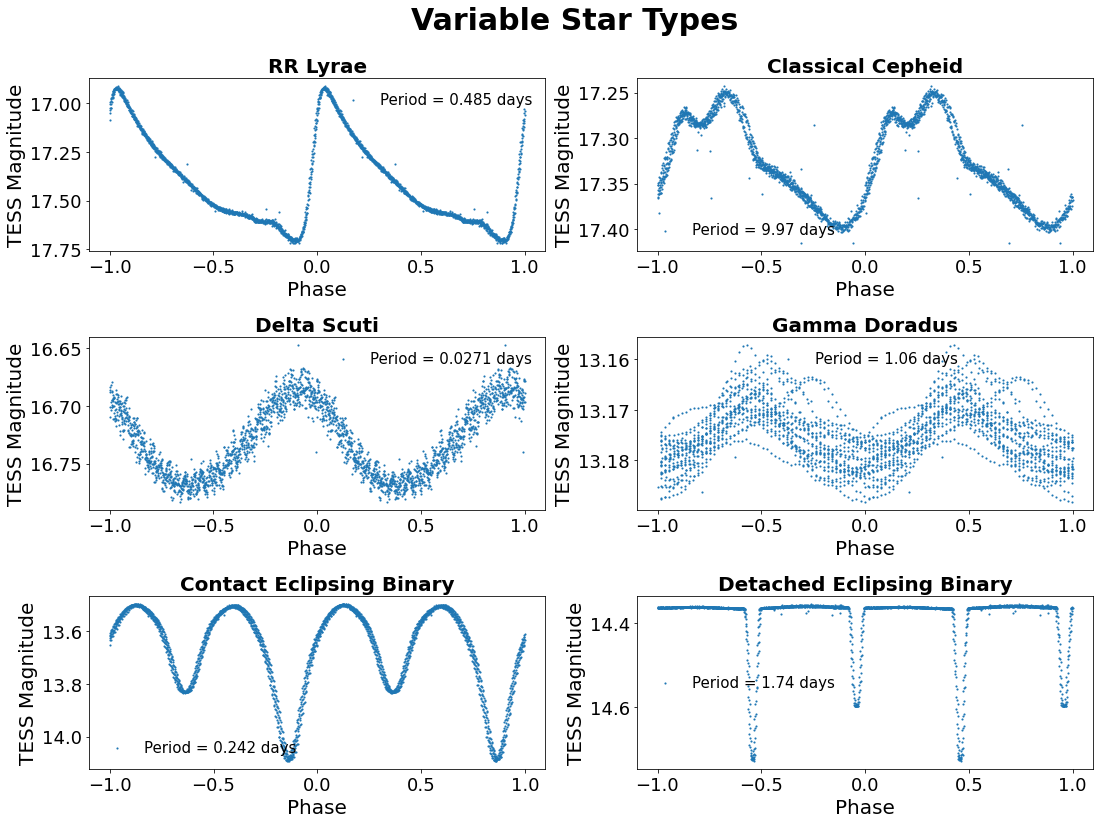

In [145]:
plt.figure(figsize=(18,25))
plt.subplots_adjust(hspace=.50,top=0.94) 

plt.subplot(6,2,1)
#RR lyrae
foldedlc(RR1[147:148])
plt.title('RR Lyrae',fontsize=20, fontweight='bold')

plt.subplot(6,2,2)
#Cepheid
foldedlc(sec1cleanDCEP[15:16])
plt.title('Classical Cepheid',fontsize=20, fontweight='bold')

plt.subplot(6,2,3) 
#Delta scuti
foldedlc(sec1cleanDSCT[7:8])
plt.title('Delta Scuti',fontsize=20, fontweight='bold')

plt.subplot(6,2,4)
#Gamma doradus
foldedlc(sec1cleanGDOR[5:6])
plt.title('Gamma Doradus',fontsize=20, fontweight='bold')

plt.subplot(6,2,5)
#contact eclipsing binary
foldedlc(sec1cleanEC[2:3])
plt.title('Contact Eclipsing Binary',fontsize=20, fontweight='bold')

plt.subplot(6,2,6)
#detached eclipsing binary
foldedlc(sec1cleanED[3:4])
plt.title('Detached Eclipsing Binary',fontsize=20, fontweight='bold')


plt.suptitle('Variable Star Types',fontsize = 30,fontweight='bold')

plt.savefig("variabletypes.png", dpi=300, bbox_inches='tight',facecolor='white')
plt.show()
